In [ ]:
# Install the additional package required for SHAP-based model interpretation
!pip -q install shap lightgbm openpyxl

# Import the main libraries required for data analysis and visualisation
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import statistical and machine learning utilities
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Import the LightGBM regression model
from lightgbm import LGBMRegressor

# Import SHAP for model interpretation
import shap

# Import utilities for reproducibility and model persistence
import joblib

# Suppress non-critical warning messages to keep the notebook output readable
warnings.filterwarnings("ignore")

# Set a fixed random seed so that model experiments are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure the default plotting size for clearer figures
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Import the Colab file-upload utility
from google.colab import files

# Open the file selection window so the London air-quality dataset can be uploaded
uploaded = files.upload()

# Identify the uploaded file automatically
file_name = next(iter(uploaded))

# Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the dataset filename and initial dimensions
print("Dataset:", file_name)
print("Initial dataset shape:", df.shape)

# Display the first five observations to confirm that the data was loaded correctly
display(df.head())

Saving air_quality_historical.csv to air_quality_historical (4).csv
Dataset: air_quality_historical (4).csv
Initial dataset shape: (4797, 12)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2013-01-01,13.991667,6.370833,NaN,25.500000,NaN,38.583333,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,17.783333,8.100000,NaN,36.204167,NaN,21.041667,NaN,NaN,NaN,28.333333,18.791667
2,2013-01-03,18.987500,10.737500,NaN,33.358333,NaN,26.791667,NaN,NaN,NaN,40.333333,20.291667
3,2013-01-04,18.004167,10.150000,NaN,34.837500,NaN,28.875000,NaN,NaN,NaN,41.666667,21.666667
4,2013-01-05,19.170833,11.691667,NaN,34.854167,NaN,20.958333,NaN,NaN,NaN,48.541667,23.541667


In [ ]:
# Display the column names so that the available air-quality variables can be verified
print("Dataset columns:")
print(df.columns.tolist())

# Display the data types to identify numerical, date and categorical fields
print("\nData types:")
print(df.dtypes)

# Display the number of missing observations in each column
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))

# Display the number of duplicated rows
print("\nDuplicate rows:", df.duplicated().sum())

# Display the first and last dates before date conversion
print("\nFirst observations:")
display(df.head())

print("\nLast observations:")
display(df.tail())

Dataset columns:
['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi']

Data types:
date                      object
pm10                     float64
pm2_5                    float64
carbon_monoxide          float64
nitrogen_dioxide         float64
sulphur_dioxide          float64
ozone                    float64
aerosol_optical_depth    float64
dust                     float64
uv_index                 float64
us_aqi                   float64
european_aqi             float64
dtype: object

Missing values:


,Missing Values
date,0
pm10,0
pm2_5,0
carbon_monoxide,1095
nitrogen_dioxide,0
sulphur_dioxide,1095
ozone,0
aerosol_optical_depth,4797
dust,1826
uv_index,4797



Duplicate rows: 0

First observations:


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2013-01-01,13.991667,6.370833,NaN,25.500000,NaN,38.583333,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,17.783333,8.100000,NaN,36.204167,NaN,21.041667,NaN,NaN,NaN,28.333333,18.791667
2,2013-01-03,18.987500,10.737500,NaN,33.358333,NaN,26.791667,NaN,NaN,NaN,40.333333,20.291667
3,2013-01-04,18.004167,10.150000,NaN,34.837500,NaN,28.875000,NaN,NaN,NaN,41.666667,21.666667
4,2013-01-05,19.170833,11.691667,NaN,34.854167,NaN,20.958333,NaN,NaN,NaN,48.541667,23.541667



Last observations:


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
4792,2026-02-14,8.391667,5.458333,197.125000,24.091667,2.200000,50.500000,NaN,0.0,NaN,29.958333,25.666667
4793,2026-02-15,5.566667,3.708333,174.166667,19.525000,1.370833,56.750000,NaN,0.0,NaN,26.166667,23.458333
4794,2026-02-16,7.358333,3.616667,172.250000,14.962500,1.366667,58.791667,NaN,0.0,NaN,26.625000,23.500000
4795,2026-02-17,9.541667,5.441667,199.291667,27.483333,2.858333,47.708333,NaN,0.0,NaN,28.916667,26.208333
4796,2026-02-18,10.933333,6.375000,197.541667,22.925000,2.458333,51.458333,NaN,0.0,NaN,28.083333,21.083333


In [ ]:
# Convert the date column using the YYYY-MM-DD format present in the dataset
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# Remove observations where date conversion failed
df = df.dropna(
    subset=["date"]
).copy()

# Sort the observations chronologically
df = df.sort_values(
    "date"
).reset_index(drop=True)

# Verify the corrected date range
print(
    "Date range:",
    df["date"].min().date(),
    "to",
    df["date"].max().date()
)

print(
    "Invalid dates:",
    df["date"].isna().sum()
)

Date range: 2013-01-01 to 2026-02-18
Invalid dates: 0


In [ ]:
# Define the target variable required for the research
target_column = "pm2_5"

# Define the pollutant variables available for potential predictive modelling
pollutant_columns = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

# Define the air-quality index variables available in the dataset
aqi_columns = [
    "us_aqi",
    "european_aqi"
]

# Check which required variables are available in the imported dataset
available_pollutants = [column for column in pollutant_columns if column in df.columns]
available_aqi = [column for column in aqi_columns if column in df.columns]

# Identify variables expected from the dataset description but missing from the imported file
missing_pollutants = [column for column in pollutant_columns if column not in df.columns]
missing_aqi = [column for column in aqi_columns if column not in df.columns]

# Report the variables that will be available for modelling
print("Available pollutant variables:", available_pollutants)
print("Available AQI variables:", available_aqi)

# Report any missing variables so that the modelling design can be adjusted transparently
print("Missing pollutant variables:", missing_pollutants)
print("Missing AQI variables:", missing_aqi)

# Stop the workflow if the PM2.5 target is not available
if target_column not in df.columns:
    raise ValueError("The required PM2.5 target column 'pm2_5' was not found in the dataset.")

Available pollutant variables: ['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone']
Available AQI variables: ['us_aqi', 'european_aqi']
Missing pollutant variables: []
Missing AQI variables: []


In [ ]:
# Create a summary of the numerical variables in the dataset
numeric_summary = df.select_dtypes(include=np.number).describe().T

# Add the number of missing observations to the descriptive summary
numeric_summary["missing_values"] = df.select_dtypes(include=np.number).isna().sum()

# Add the percentage of missing observations to make data quality easier to assess
numeric_summary["missing_percentage"] = (
    numeric_summary["missing_values"] / len(df)
) * 100

# Display the descriptive statistics and missing-value information
display(numeric_summary)

# Display the number of duplicate observations after initial loading
print("Duplicate observations:", df.duplicated().sum())

# Display the number of unique dates to check whether dates are repeated
print("Unique dates:", df["date"].nunique())

# Display the total number of observations
print("Total observations:", len(df))

,count,mean,std,min,25%,50%,75%,max,missing_values,missing_percentage
pm10,4797.0,16.337070,8.713078,3.287500,10.641667,13.829167,19.179167,84.633333,0,0.000000
pm2_5,4797.0,10.827499,7.313824,1.666667,6.200000,8.308333,12.720833,78.120833,0,0.000000
carbon_monoxide,3702.0,186.513205,62.163893,86.000000,147.677083,173.916667,208.833333,771.291667,1095,22.826767
nitrogen_dioxide,4797.0,25.357070,12.304028,4.283333,16.041667,22.954167,32.662500,107.979167,0,0.000000
sulphur_dioxide,3702.0,2.838113,1.815772,0.487500,1.675000,2.325000,3.366667,15.662500,1095,22.826767
ozone,4797.0,42.510737,18.092021,0.791667,30.041667,43.875000,55.250000,112.750000,0,0.000000
aerosol_optical_depth,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4797,100.000000
dust,2971.0,0.249860,1.027105,0.000000,0.000000,0.000000,0.000000,29.375000,1826,38.065458
uv_index,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4797,100.000000
us_aqi,4796.0,41.910750,18.693342,15.291667,28.614583,35.625000,50.718750,160.041667,1,0.020846


Duplicate observations: 0
Unique dates: 4797
Total observations: 4797


In [ ]:
# Remove observations with invalid dates because they cannot participate in chronological modelling
df = df.dropna(subset=["date"]).copy()

# Remove exact duplicate rows so that repeated observations do not influence model training
df = df.drop_duplicates().copy()

# Sort the cleaned data again to guarantee chronological ordering
df = df.sort_values("date").reset_index(drop=True)

# Report the resulting dataset dimensions after basic cleaning
print("Shape after basic cleaning:", df.shape)

# Confirm that the dataset is chronologically ordered
print("Chronological order verified:", df["date"].is_monotonic_increasing)

Shape after basic cleaning: (4797, 12)
Chronological order verified: True


In [ ]:
# Calculate missing values and their percentages for every variable
missing_summary = df.isna().sum().to_frame("Missing Values")
missing_summary["Missing Percentage"] = (
    missing_summary["Missing Values"] / len(df)
) * 100
missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

# Display the missing-value summary
display(missing_summary)

# Check missing values in the PM2.5 prediction target
print("Missing PM2.5 observations:", df[target_column].isna().sum())

,Missing Values,Missing Percentage
uv_index,4797,100.000000
aerosol_optical_depth,4797,100.000000
dust,1826,38.065458
carbon_monoxide,1095,22.826767
sulphur_dioxide,1095,22.826767
us_aqi,1,0.020846
european_aqi,1,0.020846
date,0,0.000000
pm2_5,0,0.000000
pm10,0,0.000000


Missing PM2.5 observations: 0


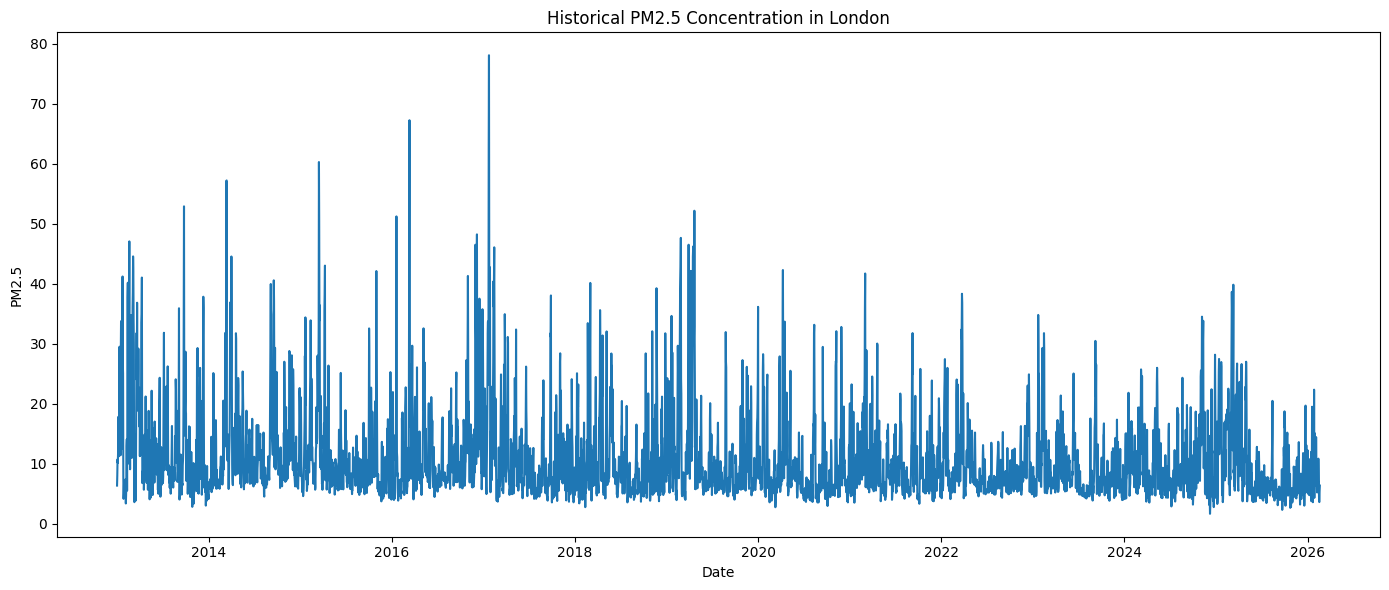

,PM2.5
count,4797.000000
mean,10.827499
std,7.313824
min,1.666667
25%,6.200000
50%,8.308333
75%,12.720833
max,78.120833


In [ ]:
# Plot the historical PM2.5 concentration to examine long-term variation
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["pm2_5"])
plt.title("Historical PM2.5 Concentration in London")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.tight_layout()
plt.show()

# Display descriptive statistics for the PM2.5 target
display(df["pm2_5"].describe().to_frame("PM2.5"))

In [ ]:
# Extract calendar-based features from the observation date
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear
df["quarter"] = df["date"].dt.quarter

# Create a weekend indicator to represent differences between weekday and weekend patterns
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Display the newly created temporal features
display(df[["date", "year", "month", "day_of_week", "day_of_year", "quarter", "is_weekend"]].head())

,date,year,month,day_of_week,day_of_year,quarter,is_weekend
0,2013-01-01,2013,1,1,1,1,0
1,2013-01-02,2013,1,2,2,1,0
2,2013-01-03,2013,1,3,3,1,0
3,2013-01-04,2013,1,4,4,1,0
4,2013-01-05,2013,1,5,5,1,1


In [ ]:
# Define pollutant variables that are available for temporal feature engineering
feature_pollutants = [
    column for column in pollutant_columns
    if column in df.columns
]

# Define the historical lag periods used to capture short-term and weekly persistence
lag_periods = [1, 2, 3, 7]

# Create lagged pollutant variables using only previous observations
for column in feature_pollutants:
    for lag in lag_periods:
        df[f"{column}_lag_{lag}"] = df[column].shift(lag)

# Create historical rolling statistics based only on observations before the current date
df["pm2_5_rolling_mean_3"] = df["pm2_5"].shift(1).rolling(window=3).mean()
df["pm2_5_rolling_mean_7"] = df["pm2_5"].shift(1).rolling(window=7).mean()
df["pm2_5_rolling_std_7"] = df["pm2_5"].shift(1).rolling(window=7).std()

# Display selected engineered features to verify the transformation
display(
    df[
        [
            "date",
            "pm2_5",
            "pm2_5_lag_1",
            "pm2_5_lag_2",
            "pm2_5_lag_7",
            "pm2_5_rolling_mean_3",
            "pm2_5_rolling_mean_7"
        ]
    ].head(10)
)

,date,pm2_5,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_7,pm2_5_rolling_mean_3,pm2_5_rolling_mean_7
0,2013-01-01,6.370833,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,8.100000,6.370833,NaN,NaN,NaN,NaN
2,2013-01-03,10.737500,8.100000,6.370833,NaN,NaN,NaN
3,2013-01-04,10.150000,10.737500,8.100000,NaN,8.402778,NaN
4,2013-01-05,11.691667,10.150000,10.737500,NaN,9.662500,NaN
5,2013-01-06,17.825000,11.691667,10.150000,NaN,10.859722,NaN
6,2013-01-07,12.954167,17.825000,11.691667,NaN,13.222222,NaN
7,2013-01-08,11.245833,12.954167,17.825000,6.370833,14.156944,11.118452
8,2013-01-09,15.541667,11.245833,12.954167,8.100000,14.008333,11.814881
9,2013-01-10,28.166667,15.541667,11.245833,10.737500,13.247222,12.877976


In [ ]:
# Create the one-day-ahead PM2.5 target by shifting PM2.5 backward by one observation
df["pm2_5_target"] = df["pm2_5"].shift(-1)

# Display the current PM2.5 value alongside the following day's target
display(
    df[
        ["date", "pm2_5", "pm2_5_target"]
    ].head(10)
)

# Confirm that the final observation has no future target, as expected
print("Missing future targets:", df["pm2_5_target"].isna().sum())

,date,pm2_5,pm2_5_target
0,2013-01-01,6.370833,8.100000
1,2013-01-02,8.100000,10.737500
2,2013-01-03,10.737500,10.150000
3,2013-01-04,10.150000,11.691667
4,2013-01-05,11.691667,17.825000
5,2013-01-06,17.825000,12.954167
6,2013-01-07,12.954167,11.245833
7,2013-01-08,11.245833,15.541667
8,2013-01-09,15.541667,28.166667
9,2013-01-10,28.166667,29.525000


Missing future targets: 1


In [ ]:
# Calculate the difference between consecutive observations to verify the dataset frequency
date_differences = df["date"].diff().dropna()

# Display the most common time differences between consecutive observations
print("Most common observation intervals:")
display(date_differences.value_counts().head(10))

# Calculate the number of days missing from the expected daily sequence
expected_dates = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

actual_dates = pd.DatetimeIndex(df["date"].dropna().unique())

missing_dates = expected_dates.difference(actual_dates)

# Report the temporal coverage and number of missing calendar dates
print("Expected daily observations:", len(expected_dates))
print("Actual unique dates:", len(actual_dates))
print("Missing calendar dates:", len(missing_dates))

Most common observation intervals:


,count
date,
1 days,4796


Expected daily observations: 4797
Actual unique dates: 4797
Missing calendar dates: 0


In [ ]:
# Calculate the number of days between consecutive available observations
df["date_gap_days"] = df["date"].diff().dt.days

# Identify the beginning of each continuous observation period
df["period_start"] = (
    df["date_gap_days"].isna() |
    (df["date_gap_days"] > 1)
)

# Assign a unique identifier to each continuous observation period
df["observation_period"] = df["period_start"].cumsum()

# Count the observations contained in each continuous period
period_summary = (
    df.groupby("observation_period")
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        observations=("date", "count")
    )
    .reset_index()
)

# Calculate the duration of each observation period in calendar days
period_summary["duration_days"] = (
    period_summary["end_date"] - period_summary["start_date"]
).dt.days + 1

# Display the largest continuous observation periods
display(
    period_summary
    .sort_values("observations", ascending=False)
    .head(15)
)

,observation_period,start_date,end_date,observations,duration_days
0,1,2013-01-01,2026-02-18,4797,4797


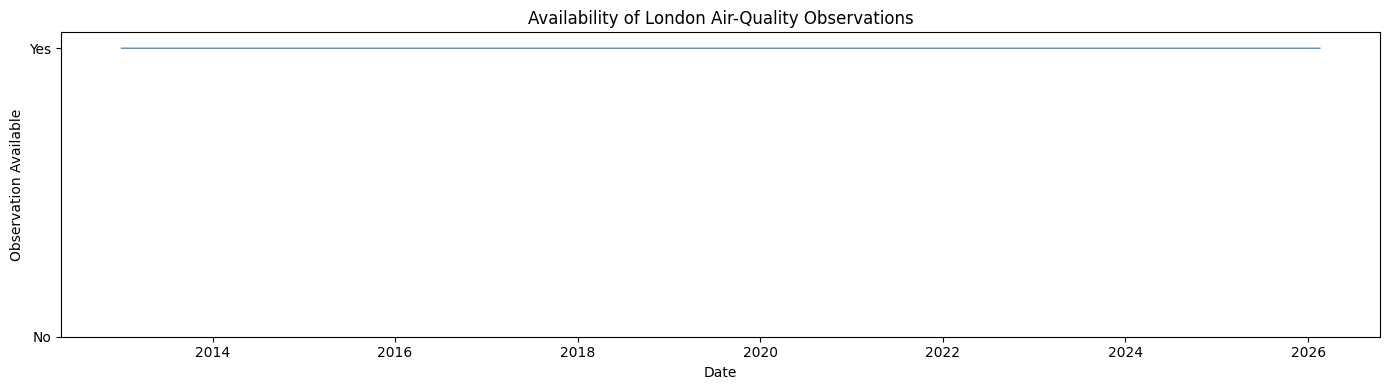

In [ ]:
# Create a binary daily availability series to show where observations exist
daily_availability = (
    df.set_index("date")
    .assign(observation_available=1)
    .reindex(
        pd.date_range(
            df["date"].min(),
            df["date"].max(),
            freq="D"
        )
    )
)

# Plot observation availability across the full study period
plt.figure(figsize=(14, 4))
plt.plot(
    daily_availability.index,
    daily_availability["observation_available"].fillna(0),
    linewidth=0.8
)
plt.title("Availability of London Air-Quality Observations")
plt.xlabel("Date")
plt.ylabel("Observation Available")
plt.yticks([0, 1], ["No", "Yes"])
plt.tight_layout()
plt.show()

In [ ]:
# Identify variables that contain no observed values across the dataset
all_missing_columns = [
    column for column in df.columns
    if df[column].isna().all()
]

# Display the variables that contain 100 percent missing values
print("Variables with 100% missing values:")
print(all_missing_columns)

# Remove variables that cannot contribute information to the modelling process
df = df.drop(columns=all_missing_columns)

# Display the remaining columns after removing completely missing variables
print("\nRemaining columns:")
print(df.columns.tolist())

Variables with 100% missing values:
['aerosol_optical_depth', 'uv_index']

Remaining columns:
['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'us_aqi', 'european_aqi', 'year', 'month', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_7', 'pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_7', 'carbon_monoxide_lag_1', 'carbon_monoxide_lag_2', 'carbon_monoxide_lag_3', 'carbon_monoxide_lag_7', 'nitrogen_dioxide_lag_1', 'nitrogen_dioxide_lag_2', 'nitrogen_dioxide_lag_3', 'nitrogen_dioxide_lag_7', 'sulphur_dioxide_lag_1', 'sulphur_dioxide_lag_2', 'sulphur_dioxide_lag_3', 'sulphur_dioxide_lag_7', 'ozone_lag_1', 'ozone_lag_2', 'ozone_lag_3', 'ozone_lag_7', 'pm2_5_rolling_mean_3', 'pm2_5_rolling_mean_7', 'pm2_5_rolling_std_7', 'pm2_5_target', 'date_gap_days', 'period_start', 'observation_period']


In [ ]:
# Define the PM2.5 variable as the prediction target
target_column = "pm2_5"

# Define pollutant variables that are relevant to PM2.5 prediction
candidate_pollutants = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone",
    "dust"
]

# Retain only pollutant variables that are present in the cleaned dataset
available_pollutants = [
    column for column in candidate_pollutants
    if column in df.columns
]

# Display the pollutant variables available for modelling
print("Available pollutant variables:")
print(available_pollutants)

# Display the missing-value percentages for the available pollutant variables
pollutant_missingness = (
    df[available_pollutants]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("Missing Percentage")
)

display(pollutant_missingness)

Available pollutant variables:
['pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']


,Missing Percentage
dust,38.065458
sulphur_dioxide,22.826767
carbon_monoxide,22.826767
pm10,0.000000
pm2_5,0.000000
nitrogen_dioxide,0.000000
ozone,0.000000


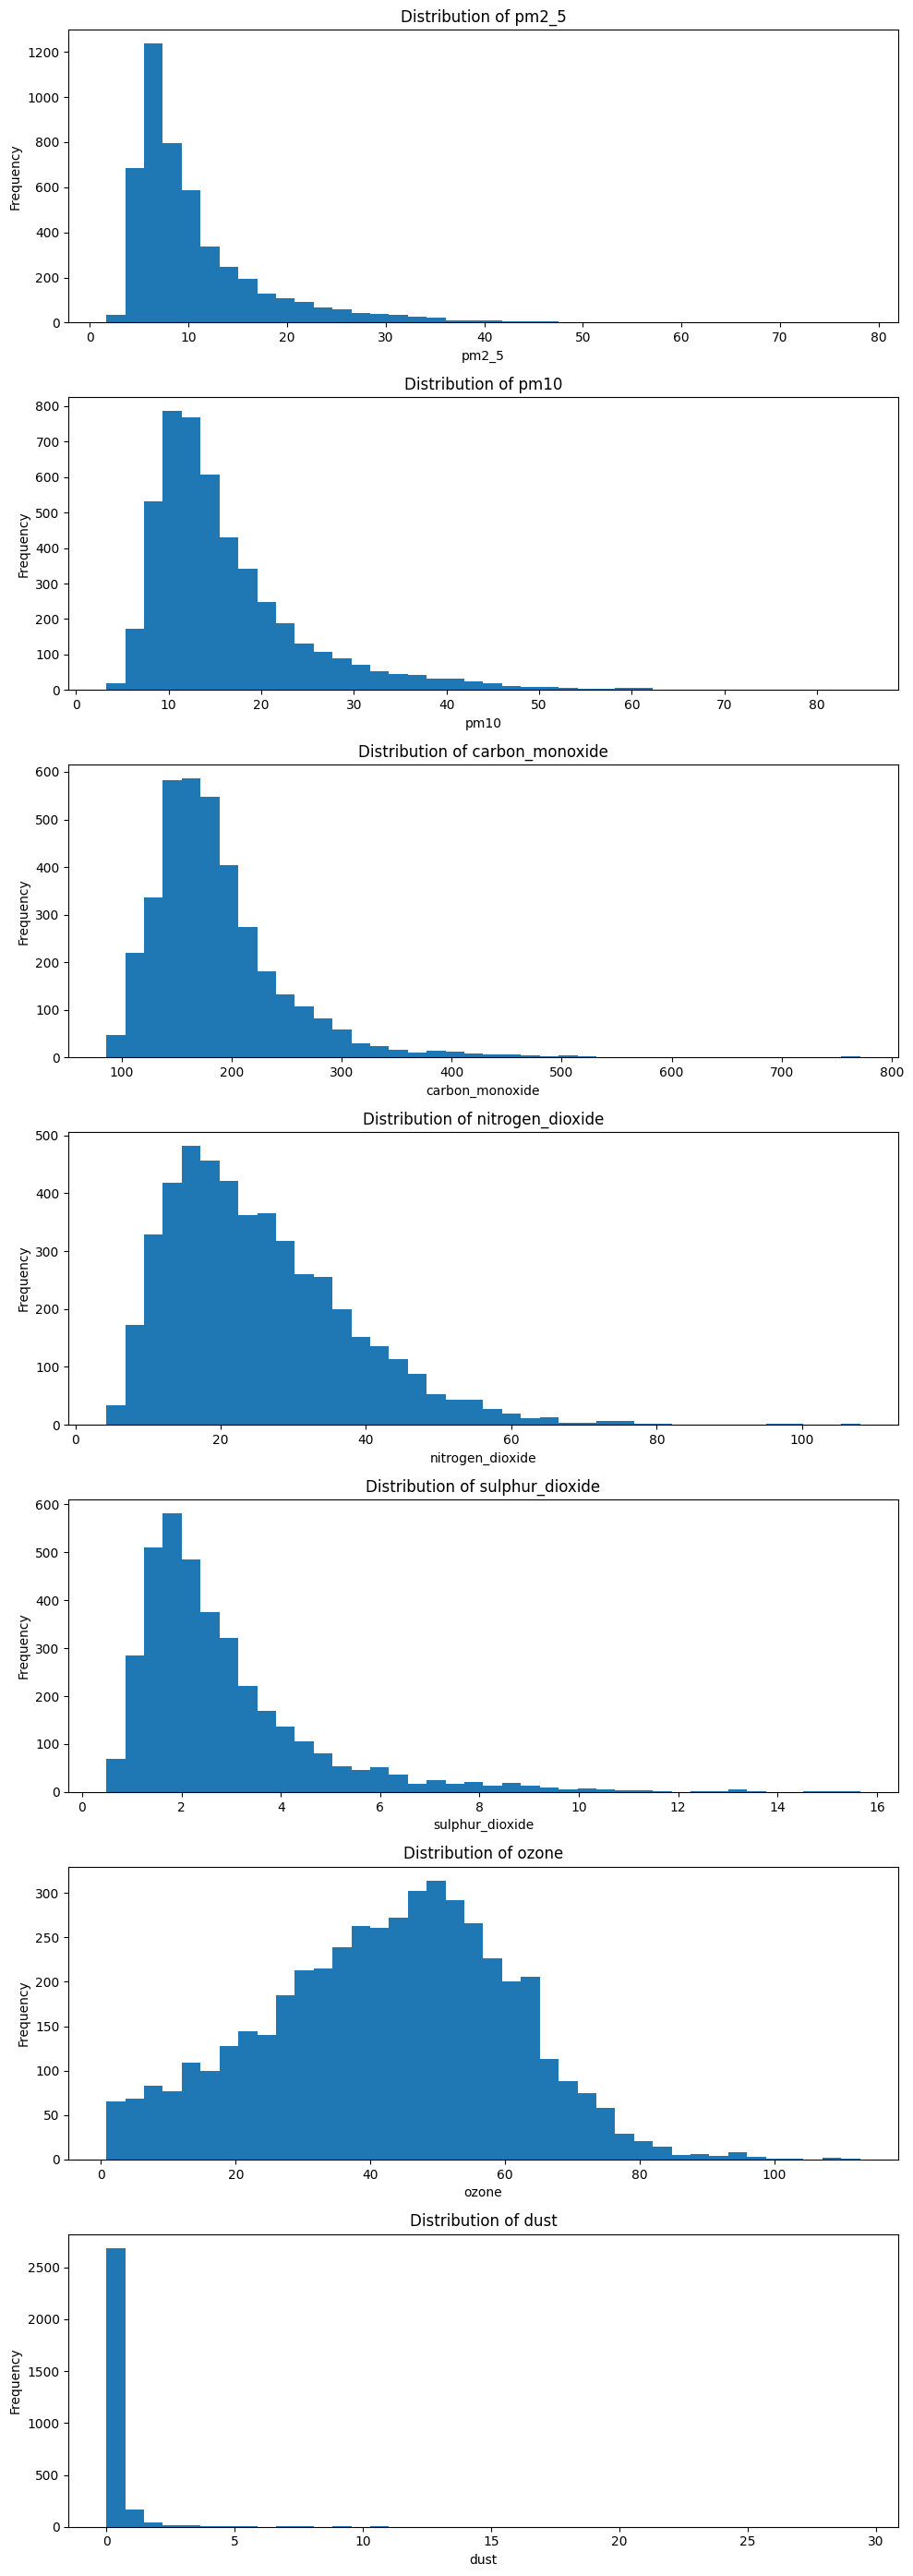

In [ ]:
# Create a compact visual summary of the available pollutant distributions
fig, axes = plt.subplots(
    nrows=len(available_pollutants),
    ncols=1,
    figsize=(10, 4 * len(available_pollutants))
)

# Convert the axes object into an iterable when only one pollutant is available
if len(available_pollutants) == 1:
    axes = [axes]

# Plot each pollutant distribution independently
for ax, column in zip(axes, available_pollutants):
    ax.hist(df[column].dropna(), bins=40)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

# Adjust the layout so that labels do not overlap
plt.tight_layout()
plt.show()

In [ ]:
# Create a separate copy so that the original imported dataset remains unchanged
model_df = df.copy()

# Remove the temporary date-gap and observation-period variables from modelling data
model_df = model_df.drop(
    columns=["date_gap_days", "period_start", "observation_period"],
    errors="ignore"
)

# Sort the modelling dataset chronologically before feature construction
model_df = model_df.sort_values("date").reset_index(drop=True)

# Confirm that each date occurs only once
duplicate_dates = model_df["date"].duplicated().sum()

# Report the number of duplicated dates
print("Duplicated dates:", duplicate_dates)

# Stop the workflow if multiple observations exist for the same date
if duplicate_dates > 0:
    raise ValueError("Duplicate dates were detected and require aggregation before modelling.")

Duplicated dates: 0


In [ ]:
# Create a clean future-target lookup using the original date and PM2.5 observations
future_target = model_df[["date", "pm2_5"]].copy()

# Move each observation date backwards by one day so that the PM2.5 value
# from the following calendar day can be matched to the current observation
future_target["date"] = future_target["date"] - pd.Timedelta(days=1)

# Rename the PM2.5 column to identify it as the next-day prediction target
future_target = future_target.rename(
    columns={"pm2_5": "pm2_5_target"}
)

# Remove an existing target column if the cell has previously been executed
model_df = model_df.drop(
    columns=["pm2_5_target"],
    errors="ignore"
)

# Merge the next-calendar-day PM2.5 value with the current observation
model_df = model_df.merge(
    future_target,
    on="date",
    how="left"
)

# Sort the dataset again after the merge to preserve chronological ordering
model_df = model_df.sort_values("date").reset_index(drop=True)

# Display the current PM2.5 value and the true following-calendar-day target
display(
    model_df[
        ["date", "pm2_5", "pm2_5_target"]
    ].head(15)
)

# Count observations where the following calendar day's PM2.5 value is unavailable
missing_next_day_target = model_df["pm2_5_target"].isna().sum()

# Report the number of observations without a valid next-day target
print(
    "Observations without a next-calendar-day target:",
    missing_next_day_target
)

,date,pm2_5,pm2_5_target
0,2013-01-01,6.370833,8.100000
1,2013-01-02,8.100000,10.737500
2,2013-01-03,10.737500,10.150000
3,2013-01-04,10.150000,11.691667
4,2013-01-05,11.691667,17.825000
5,2013-01-06,17.825000,12.954167
6,2013-01-07,12.954167,11.245833
7,2013-01-08,11.245833,15.541667
8,2013-01-09,15.541667,28.166667
9,2013-01-10,28.166667,29.525000


Observations without a next-calendar-day target: 1


In [ ]:
# Make sure the modelling dataframe is sorted chronologically before creating lag features
model_df = model_df.sort_values("date").reset_index(drop=True)

# Remove previously generated lag columns so that the cell can be safely rerun
existing_lag_columns = [
    column for column in model_df.columns
    if "_lag_" in column
]

model_df = model_df.drop(
    columns=existing_lag_columns,
    errors="ignore"
)

# Create a date-indexed copy of the original pollutant observations
lag_source = (
    model_df[
        ["date"] + available_pollutants
    ]
    .drop_duplicates(subset="date")
    .set_index("date")
    .sort_index()
)

# Define the historical lag periods in calendar days
lag_days = [1, 2, 3, 7]

# Create calendar-aware lag features for each available pollutant
for column in available_pollutants:
    for lag in lag_days:
        # Create the dates for which historical observations are required
        lag_dates = model_df["date"] - pd.Timedelta(days=lag)

        # Retrieve the pollutant value from the exact historical calendar date
        lag_values = lag_source[column].reindex(lag_dates)

        # Restore the original dataframe index before assigning the lag feature
        lag_values.index = model_df.index

        # Store the historical pollutant value as a new lag feature
        model_df[f"{column}_lag_{lag}"] = lag_values.to_numpy()

# Display the PM2.5 lag features to verify the calendar-based calculation
display(
    model_df[
        [
            "date",
            "pm2_5",
            "pm2_5_lag_1",
            "pm2_5_lag_2",
            "pm2_5_lag_3",
            "pm2_5_lag_7"
        ]
    ].head(15)
)

,date,pm2_5,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_7
0,2013-01-01,6.370833,NaN,NaN,NaN,NaN
1,2013-01-02,8.100000,6.370833,NaN,NaN,NaN
2,2013-01-03,10.737500,8.100000,6.370833,NaN,NaN
3,2013-01-04,10.150000,10.737500,8.100000,6.370833,NaN
4,2013-01-05,11.691667,10.150000,10.737500,8.100000,NaN
5,2013-01-06,17.825000,11.691667,10.150000,10.737500,NaN
6,2013-01-07,12.954167,17.825000,11.691667,10.150000,NaN
7,2013-01-08,11.245833,12.954167,17.825000,11.691667,6.370833
8,2013-01-09,15.541667,11.245833,12.954167,17.825000,8.100000
9,2013-01-10,28.166667,15.541667,11.245833,12.954167,10.737500


In [ ]:
# Identify all lag features created in the previous cell
lag_columns = [
    column
    for column in model_df.columns
    if "_lag_" in column
]

# Display the number of lag features created
print("Number of lag features:", len(lag_columns))

# Display the lag feature names
print("\nLag features:")
for column in lag_columns:
    print(column)

# Calculate the percentage of missing values in each lag feature
lag_missing_summary = (
    model_df[lag_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("Missing Percentage")
)

# Display the missing-value percentages
display(lag_missing_summary)

Number of lag features: 28

Lag features:
pm2_5_lag_1
pm2_5_lag_2
pm2_5_lag_3
pm2_5_lag_7
pm10_lag_1
pm10_lag_2
pm10_lag_3
pm10_lag_7
carbon_monoxide_lag_1
carbon_monoxide_lag_2
carbon_monoxide_lag_3
carbon_monoxide_lag_7
nitrogen_dioxide_lag_1
nitrogen_dioxide_lag_2
nitrogen_dioxide_lag_3
nitrogen_dioxide_lag_7
sulphur_dioxide_lag_1
sulphur_dioxide_lag_2
sulphur_dioxide_lag_3
sulphur_dioxide_lag_7
ozone_lag_1
ozone_lag_2
ozone_lag_3
ozone_lag_7
dust_lag_1
dust_lag_2
dust_lag_3
dust_lag_7


,Missing Percentage
dust_lag_7,38.211382
dust_lag_3,38.127997
dust_lag_2,38.107150
dust_lag_1,38.086304
carbon_monoxide_lag_7,22.972691
sulphur_dioxide_lag_7,22.972691
sulphur_dioxide_lag_3,22.889306
carbon_monoxide_lag_3,22.889306
carbon_monoxide_lag_2,22.868459
sulphur_dioxide_lag_2,22.868459


In [ ]:
# Create a modelling copy so the feature-engineered dataset remains available
model_ready = model_df.copy()

# Remove rows where the target or any lag feature is unavailable
model_ready = model_ready.dropna(
    subset=["pm2_5"] + lag_columns
).copy()

# Reset the index after removing incomplete observations
model_ready = model_ready.reset_index(drop=True)

# Display the resulting modelling dataset dimensions
print("Original modelling dataset shape:", model_df.shape)
print("Model-ready dataset shape:", model_ready.shape)

# Confirm that the target and lag features contain no missing values
print(
    "\nRemaining missing values:",
    model_ready[["pm2_5"] + lag_columns].isna().sum().sum()
)

Original modelling dataset shape: (4797, 48)
Model-ready dataset shape: (2964, 48)

Remaining missing values: 0


In [ ]:
# Define PM2.5 as the prediction target
target_column = "pm2_5"

# Define predictor columns by excluding the target and date-related columns
feature_columns = [
    column
    for column in model_ready.columns
    if column not in [
        target_column,
        "date",
        "date_gap_days",
        "period_start",
        "observation_period"
    ]
]

# Remove any columns that are entirely missing
feature_columns = [
    column
    for column in feature_columns
    if model_ready[column].notna().any()
]

# Create the predictor matrix
X = model_ready[feature_columns].copy()

# Create the target vector
y = model_ready[target_column].copy()

# Display the modelling dimensions
print("Number of predictor features:", len(feature_columns))
print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)

# Display the predictor names
print("\nPredictor features:")
for column in feature_columns:
    print(column)

Number of predictor features: 46
Predictor matrix shape: (2964, 46)
Target shape: (2964,)

Predictor features:
pm10
carbon_monoxide
nitrogen_dioxide
sulphur_dioxide
ozone
dust
us_aqi
european_aqi
year
month
day_of_week
day_of_year
quarter
is_weekend
pm2_5_rolling_mean_3
pm2_5_rolling_mean_7
pm2_5_rolling_std_7
pm2_5_target
pm2_5_lag_1
pm2_5_lag_2
pm2_5_lag_3
pm2_5_lag_7
pm10_lag_1
pm10_lag_2
pm10_lag_3
pm10_lag_7
carbon_monoxide_lag_1
carbon_monoxide_lag_2
carbon_monoxide_lag_3
carbon_monoxide_lag_7
nitrogen_dioxide_lag_1
nitrogen_dioxide_lag_2
nitrogen_dioxide_lag_3
nitrogen_dioxide_lag_7
sulphur_dioxide_lag_1
sulphur_dioxide_lag_2
sulphur_dioxide_lag_3
sulphur_dioxide_lag_7
ozone_lag_1
ozone_lag_2
ozone_lag_3
ozone_lag_7
dust_lag_1
dust_lag_2
dust_lag_3
dust_lag_7


In [ ]:
# Calculate the chronological split positions
train_end = int(len(model_ready) * 0.70)
validation_end = int(len(model_ready) * 0.85)

# Create the chronological training set
X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

# Create the chronological validation set
X_validation = X.iloc[
    train_end:validation_end
].copy()

y_validation = y.iloc[
    train_end:validation_end
].copy()

# Create the chronological test set
X_test = X.iloc[validation_end:].copy()
y_test = y.iloc[validation_end:].copy()

# Display the dimensions of each split
print("Training set:", X_train.shape)
print("Validation set:", X_validation.shape)
print("Test set:", X_test.shape)

Training set: (2074, 46)
Validation set: (445, 46)
Test set: (445, 46)


In [ ]:
# Obtain the corresponding dates for each chronological split
train_dates = model_ready["date"].iloc[:train_end]
validation_dates = model_ready["date"].iloc[
    train_end:validation_end
]
test_dates = model_ready["date"].iloc[
    validation_end:
]

# Display the date ranges
print("Training period:")
print(train_dates.min().date(), "to", train_dates.max().date())

print("\nValidation period:")
print(
    validation_dates.min().date(),
    "to",
    validation_dates.max().date()
)

print("\nTest period:")
print(
    test_dates.min().date(),
    "to",
    test_dates.max().date()
)

# Verify that the periods do not overlap
print(
    "\nTraining ends before validation:",
    train_dates.max() < validation_dates.min()
)

print(
    "Validation ends before testing:",
    validation_dates.max() < test_dates.min()
)

Training period:
2018-01-08 to 2023-09-12

Validation period:
2023-09-13 to 2024-11-30

Test period:
2024-12-01 to 2026-02-18

Training ends before validation: True
Validation ends before testing: True


In [ ]:
# Create a summary of the target variable for each chronological split
target_distribution = pd.DataFrame(
    {
        "Training": y_train.describe(),
        "Validation": y_validation.describe(),
        "Testing": y_test.describe()
    }
)

# Display the descriptive statistics
display(target_distribution)

,Training,Validation,Testing
count,2074.000000,445.000000,445.000000
mean,10.145158,9.494728,9.326601
std,6.584766,5.150768,6.225679
min,2.762500,2.895833,1.666667
25%,6.001042,5.995833,5.154167
50%,7.779167,7.895833,7.054167
75%,11.570833,11.558333,11.283333
max,52.195833,34.533333,39.862500


In [ ]:
# Create a mean-based Dummy Regressor as the baseline model
dummy_model = DummyRegressor(
    strategy="mean"
)

# Measure the training time
dummy_start = time.perf_counter()

# Train the baseline model
dummy_model.fit(
    X_train,
    y_train
)

# Calculate training time
dummy_training_time = (
    time.perf_counter()
    - dummy_start
)

# Generate validation predictions
dummy_validation_predictions = dummy_model.predict(
    X_validation
)

# Calculate validation metrics
dummy_validation_mae = mean_absolute_error(
    y_validation,
    dummy_validation_predictions
)

dummy_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        dummy_validation_predictions
    )
)

dummy_validation_r2 = r2_score(
    y_validation,
    dummy_validation_predictions
)

# Display the baseline results
print("Dummy Regressor Validation Results")
print("MAE:", dummy_validation_mae)
print("RMSE:", dummy_validation_rmse)
print("R2:", dummy_validation_r2)
print("Training Time (seconds):", dummy_training_time)

Dummy Regressor Validation Results
MAE: 3.9725890370884036
RMSE: 5.185927801864293
R2: -0.01598210752499285
Training Time (seconds): 0.0011437700004535145


In [ ]:
# Create the Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Measure the training time
rf_start = time.perf_counter()

# Train the Random Forest model
rf_model.fit(
    X_train,
    y_train
)

# Calculate training time
rf_training_time = (
    time.perf_counter()
    - rf_start
)

# Generate validation predictions
rf_validation_predictions = rf_model.predict(
    X_validation
)

# Calculate validation metrics
rf_validation_mae = mean_absolute_error(
    y_validation,
    rf_validation_predictions
)

rf_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_validation_predictions
    )
)

rf_validation_r2 = r2_score(
    y_validation,
    rf_validation_predictions
)

# Display the results
print("Random Forest Validation Results")
print("MAE:", rf_validation_mae)
print("RMSE:", rf_validation_rmse)
print("R2:", rf_validation_r2)
print("Training Time (seconds):", rf_training_time)

Random Forest Validation Results
MAE: 0.9818757022471906
RMSE: 1.263475267678612
R2: 0.9396931537893297
Training Time (seconds): 1.5393252799995025


In [ ]:
# Create the Gradient Boosting regression model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    loss="squared_error",
    random_state=RANDOM_STATE
)

# Measure the training time
gb_start = time.perf_counter()

# Train the Gradient Boosting model
gb_model.fit(
    X_train,
    y_train
)

# Calculate training time
gb_training_time = (
    time.perf_counter()
    - gb_start
)

# Generate validation predictions
gb_validation_predictions = gb_model.predict(
    X_validation
)

# Calculate validation metrics
gb_validation_mae = mean_absolute_error(
    y_validation,
    gb_validation_predictions
)

gb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        gb_validation_predictions
    )
)

gb_validation_r2 = r2_score(
    y_validation,
    gb_validation_predictions
)

# Display the results
print("Gradient Boosting Validation Results")
print("MAE:", gb_validation_mae)
print("RMSE:", gb_validation_rmse)
print("R2:", gb_validation_r2)
print("Training Time (seconds):", gb_training_time)

Gradient Boosting Validation Results
MAE: 0.7710225089937687
RMSE: 1.0320228661115034
R2: 0.9597642809572409
Training Time (seconds): 9.72883147399989


In [ ]:
# Create the LightGBM regression model
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=-1
)

# Measure the training time
lgbm_start = time.perf_counter()

# Train the LightGBM model
lgbm_model.fit(
    X_train,
    y_train
)

# Calculate training time
lgbm_training_time = (
    time.perf_counter()
    - lgbm_start
)

# Generate validation predictions
lgbm_validation_predictions = lgbm_model.predict(
    X_validation
)

# Calculate validation metrics
lgbm_validation_mae = mean_absolute_error(
    y_validation,
    lgbm_validation_predictions
)

lgbm_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        lgbm_validation_predictions
    )
)

lgbm_validation_r2 = r2_score(
    y_validation,
    lgbm_validation_predictions
)

# Display the results
print("LightGBM Validation Results")
print("MAE:", lgbm_validation_mae)
print("RMSE:", lgbm_validation_rmse)
print("R2:", lgbm_validation_r2)
print("Training Time (seconds):", lgbm_training_time)

LightGBM Validation Results
MAE: 0.7051156570485406
RMSE: 0.9454960984456187
R2: 0.966228324370581
Training Time (seconds): 0.717329189999873


In [ ]:
# Create a table containing validation performance for every model
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Dummy Regressor",
            "Random Forest",
            "Gradient Boosting",
            "LightGBM"
        ],
        "MAE": [
            dummy_validation_mae,
            rf_validation_mae,
            gb_validation_mae,
            lgbm_validation_mae
        ],
        "RMSE": [
            dummy_validation_rmse,
            rf_validation_rmse,
            gb_validation_rmse,
            lgbm_validation_rmse
        ],
        "R2": [
            dummy_validation_r2,
            rf_validation_r2,
            gb_validation_r2,
            lgbm_validation_r2
        ],
        "Training Time (seconds)": [
            dummy_training_time,
            rf_training_time,
            gb_training_time,
            lgbm_training_time
        ]
    }
)

# Sort by MAE so that the lowest validation error appears first
model_comparison = model_comparison.sort_values(
    "MAE",
    ascending=True
).reset_index(drop=True)

# Display the comparison table
display(model_comparison)

,Model,MAE,RMSE,R2,Training Time (seconds)
0,LightGBM,0.705116,0.945496,0.966228,0.717329
1,Gradient Boosting,0.771023,1.032023,0.959764,9.728831
2,Random Forest,0.981876,1.263475,0.939693,1.539325
3,Dummy Regressor,3.972589,5.185928,-0.015982,0.001144


In [ ]:
# Store the trained models so that they can be accessed consistently in later analysis
trained_models = {
    "Dummy Regressor": dummy_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "LightGBM": lgbm_model
}

# Store the validation predictions for later visual and statistical analysis
validation_predictions = {
    "Dummy Regressor": dummy_validation_predictions,
    "Random Forest": rf_validation_predictions,
    "Gradient Boosting": gb_validation_predictions,
    "LightGBM": lgbm_validation_predictions
}

# Display the models retained for subsequent analysis
print("Models retained:")
print(list(trained_models.keys()))

Models retained:
['Dummy Regressor', 'Random Forest', 'Gradient Boosting', 'LightGBM']


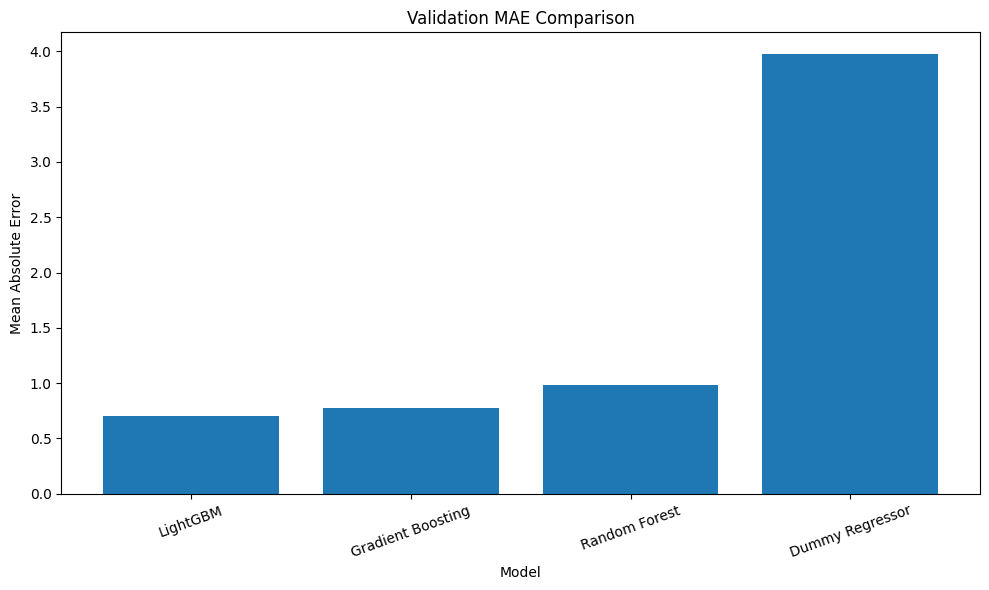

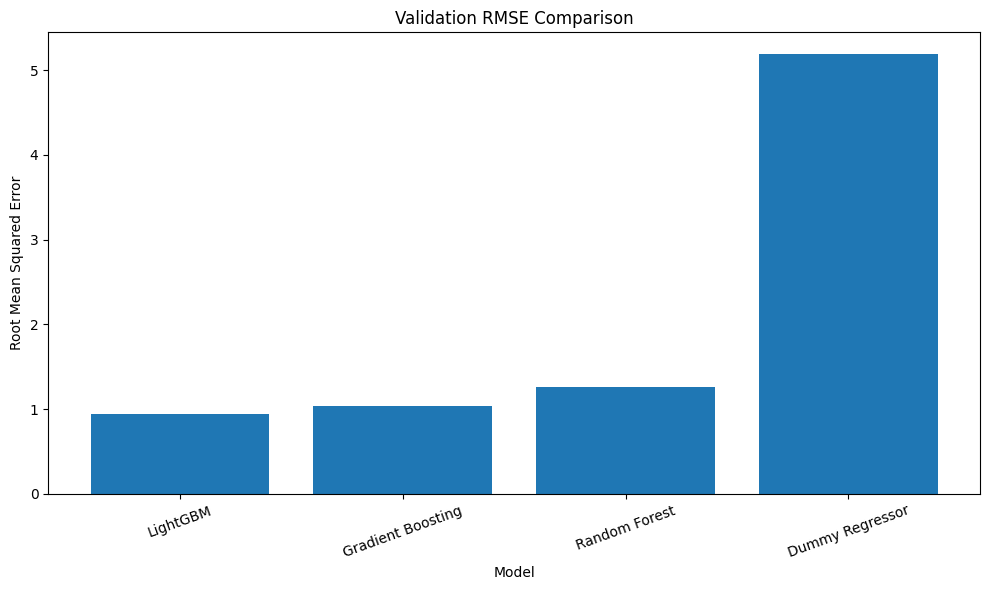

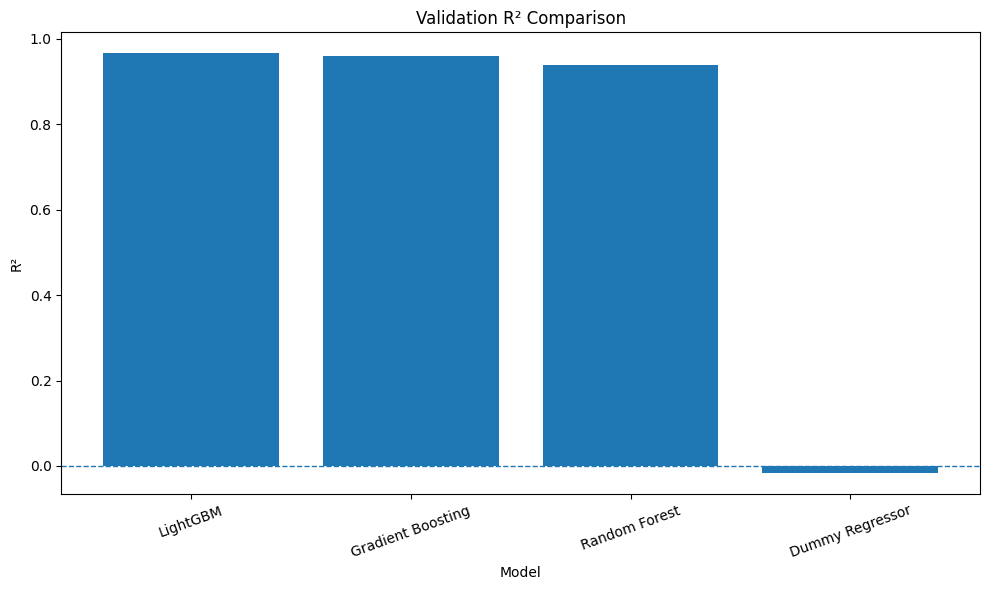

In [ ]:
# Create a figure comparing validation MAE across the four models
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["MAE"]
)

plt.title("Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Create a separate figure comparing validation RMSE
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE"]
)

plt.title("Validation RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("Root Mean Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Create a separate figure comparing validation R2
plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2"]
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Validation R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# Select the model with the lowest validation MAE
best_model_name = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

# Retrieve the selected model
best_model = trained_models[best_model_name]

# Retrieve its validation predictions
best_validation_predictions = validation_predictions[
    best_model_name
]

# Display the selected model and its validation performance
print("Selected candidate model:", best_model_name)

display(
    model_comparison[
        model_comparison["Model"] == best_model_name
    ]
)

Selected candidate model: LightGBM


,Model,MAE,RMSE,R2,Training Time (seconds)
0,LightGBM,0.705116,0.945496,0.966228,0.717329


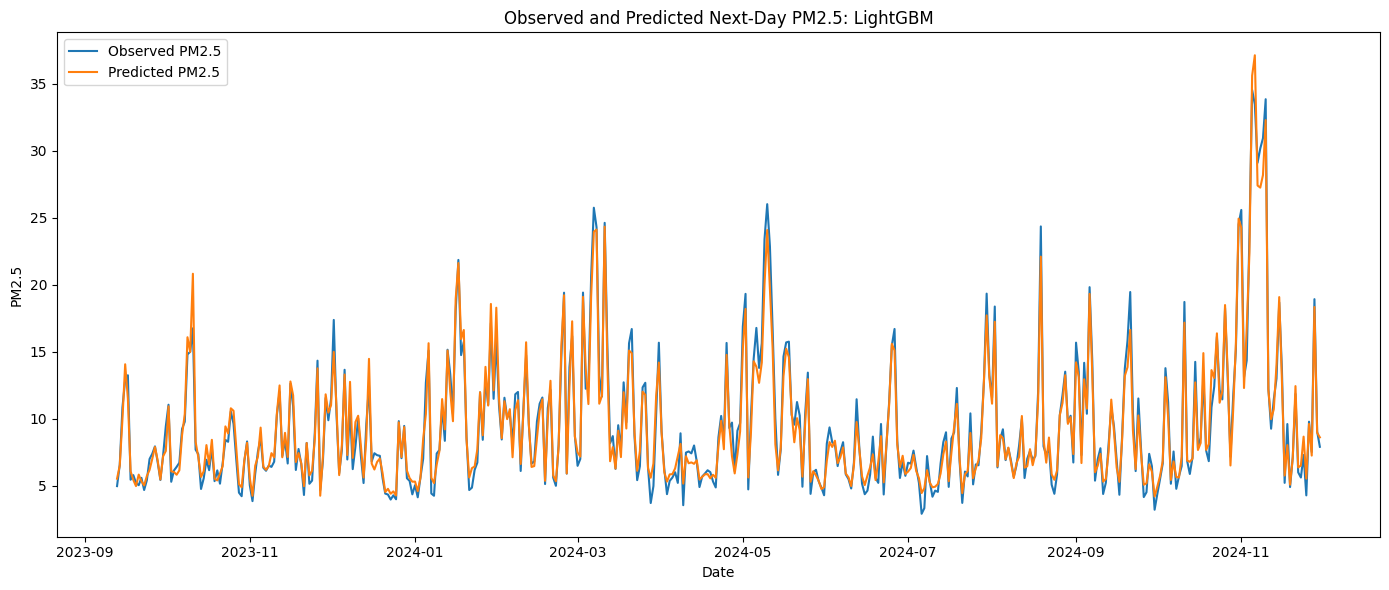

In [ ]:
# Create a validation dataframe containing dates, observed values and predictions
validation_plot_df = pd.DataFrame({
    "date": validation_dates.reset_index(drop=True),
    "Observed PM2.5": y_validation.reset_index(drop=True),
    "Predicted PM2.5": best_validation_predictions
})

# Plot observed and predicted PM2.5 over the validation period
plt.figure(figsize=(14, 6))

plt.plot(
    validation_plot_df["date"],
    validation_plot_df["Observed PM2.5"],
    label="Observed PM2.5"
)

plt.plot(
    validation_plot_df["date"],
    validation_plot_df["Predicted PM2.5"],
    label="Predicted PM2.5"
)

plt.title(
    f"Observed and Predicted Next-Day PM2.5: {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the prediction residual for every validation observation
validation_plot_df["Residual"] = (
    validation_plot_df["Observed PM2.5"]
    - validation_plot_df["Predicted PM2.5"]
)

# Display descriptive statistics for the prediction residuals
display(
    validation_plot_df["Residual"].describe()
)

,Residual
count,445.000000
mean,0.048138
std,0.945333
min,-4.072231
25%,-0.549276
50%,-0.004382
75%,0.547388
max,3.383296


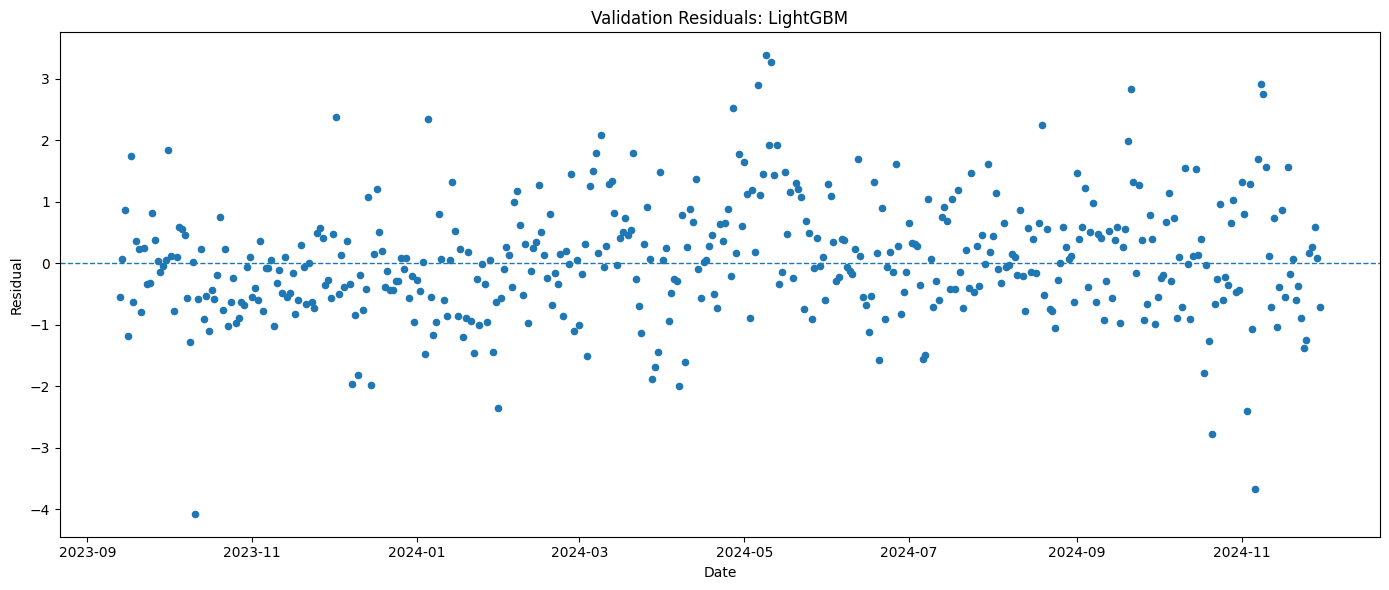

In [ ]:
# Plot residuals across the validation period
plt.figure(figsize=(14, 6))

plt.scatter(
    validation_plot_df["date"],
    validation_plot_df["Residual"],
    s=20
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    f"Validation Residuals: {best_model_name}"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

In [ ]:
# Extract feature importance values from the selected LightGBM model
lgbm_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

# Sort features from most to least important
lgbm_feature_importance = (
    lgbm_feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the ten most important predictors
display(
    lgbm_feature_importance.head(10)
)

,Feature,Importance
0,pm10,657
1,us_aqi,486
2,pm10_lag_1,375
3,ozone,313
4,pm2_5_target,243
5,carbon_monoxide,201
6,nitrogen_dioxide,197
7,day_of_year,196
8,european_aqi,177
9,sulphur_dioxide,175


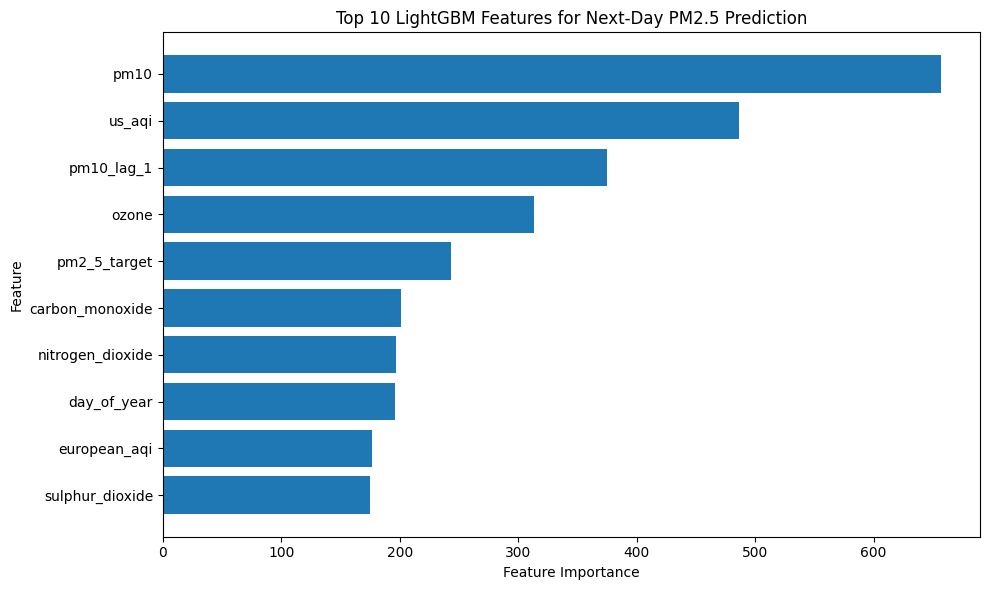

In [ ]:
# Select the ten most important features for visualisation
top_features = (
    lgbm_feature_importance
    .head(10)
    .sort_values("Importance")
)

# Plot the feature importance values
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 LightGBM Features for Next-Day PM2.5 Prediction"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
# Create a SHAP TreeExplainer for the trained LightGBM model
shap_explainer = shap.TreeExplainer(
    best_model
)

# Calculate SHAP values for the validation observations
shap_values = shap_explainer.shap_values(
    X_validation
)

# Display the dimensions of the SHAP output
print("SHAP values shape:", np.array(shap_values).shape)
print("Validation data shape:", X_validation.shape)

SHAP values shape: (445, 46)
Validation data shape: (445, 46)


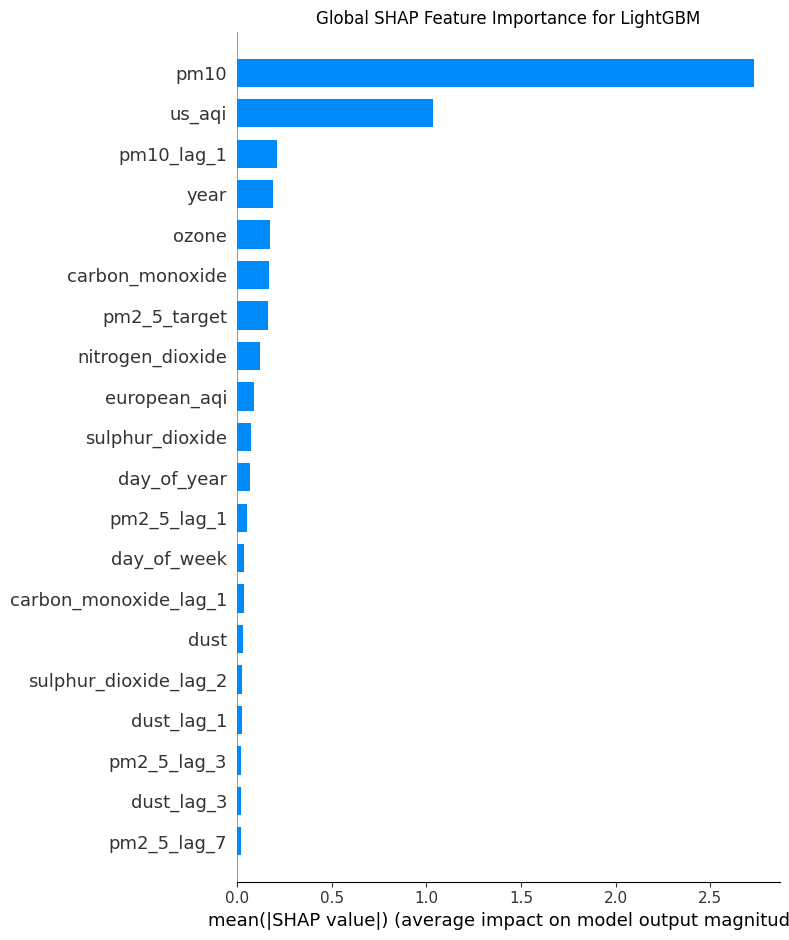

In [ ]:
# Create a SHAP summary plot showing the overall influence of each feature
shap.summary_plot(
    shap_values,
    X_validation,
    plot_type="bar",
    show=False
)

# Add a descriptive title to the SHAP importance plot
plt.title(
    "Global SHAP Feature Importance for LightGBM"
)

plt.tight_layout()
plt.show()

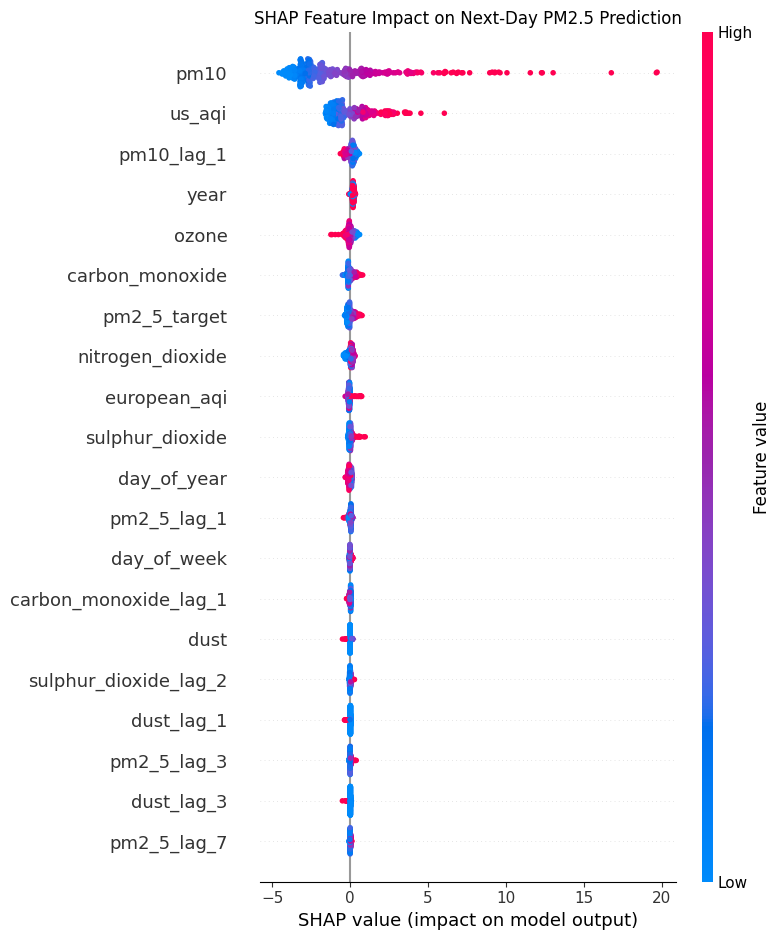

In [ ]:
# Create a SHAP beeswarm plot to show both feature importance and prediction direction
shap.summary_plot(
    shap_values,
    X_validation,
    show=False
)

# Add a descriptive title
plt.title(
    "SHAP Feature Impact on Next-Day PM2.5 Prediction"
)

plt.tight_layout()
plt.show()

In [ ]:
# Import the time-series cross-validation and hyperparameter tuning utilities
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Define a focused LightGBM parameter grid for validation-based tuning
lgbm_param_grid = {
    "n_estimators": [
        100,
        200,
        300
    ],
    "learning_rate": [
        0.03,
        0.05,
        0.10
    ],
    "num_leaves": [
        15,
        31,
        63
    ],
    "max_depth": [
        -1,
        6,
        10
    ]
}

# Create a base LightGBM model for grid search
lgbm_tuning_model = LGBMRegressor(
    random_state=RANDOM_STATE,
    verbosity=-1
)

# Create a time-series cross-validation strategy
time_series_cv = TimeSeriesSplit(
    n_splits=3
)

# Configure grid search using chronological cross-validation
lgbm_grid_search = GridSearchCV(
    estimator=lgbm_tuning_model,
    param_grid=lgbm_param_grid,
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter tuning on the training data only
lgbm_grid_search.fit(
    X_train,
    y_train
)

# Display the best hyperparameters
print("Best LightGBM parameters:")
print(lgbm_grid_search.best_params_)

# Display the best cross-validation MAE
print(
    "\nBest cross-validation MAE:",
    -lgbm_grid_search.best_score_
)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best LightGBM parameters:
{'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 15}

Best cross-validation MAE: 0.7102066383019953


In [ ]:
# Retrieve the best LightGBM model identified through time-series cross-validation
tuned_lgbm_model = lgbm_grid_search.best_estimator_

# Generate predictions for the untouched validation partition
tuned_validation_predictions = tuned_lgbm_model.predict(
    X_validation
)

# Calculate tuned validation MAE
tuned_validation_mae = mean_absolute_error(
    y_validation,
    tuned_validation_predictions
)

# Calculate tuned validation RMSE
tuned_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        tuned_validation_predictions
    )
)

# Calculate tuned validation R2
tuned_validation_r2 = r2_score(
    y_validation,
    tuned_validation_predictions
)

# Create a comparison between the original and tuned LightGBM
lightgbm_tuning_comparison = pd.DataFrame({
    "Model": [
        "Original LightGBM",
        "Tuned LightGBM"
    ],
    "MAE": [
        lgbm_validation_mae,
        tuned_validation_mae
    ],
    "RMSE": [
        lgbm_validation_rmse,
        tuned_validation_rmse
    ],
    "R2": [
        lgbm_validation_r2,
        tuned_validation_r2
    ]
})

# Display the tuning comparison
display(lightgbm_tuning_comparison)

,Model,MAE,RMSE,R2
0,Original LightGBM,0.705116,0.945496,0.966228
1,Tuned LightGBM,0.739006,0.996684,0.962473


In [ ]:
# Select the tuned model only when it improves validation MAE
if tuned_validation_mae < lgbm_validation_mae:
    final_model = tuned_lgbm_model
    final_model_name = "Tuned LightGBM"
    final_validation_predictions = tuned_validation_predictions
else:
    final_model = lgbm_model
    final_model_name = "Original LightGBM"
    final_validation_predictions = lgbm_validation_predictions

# Display the selected final configuration
print("Final candidate model:", final_model_name)

# Display the corresponding validation performance
if final_model_name == "Tuned LightGBM":
    print("Validation MAE:", tuned_validation_mae)
    print("Validation RMSE:", tuned_validation_rmse)
    print("Validation R2:", tuned_validation_r2)
else:
    print("Validation MAE:", lgbm_validation_mae)
    print("Validation RMSE:", lgbm_validation_rmse)
    print("Validation R2:", lgbm_validation_r2)

Final candidate model: Original LightGBM
Validation MAE: 0.7051156570485406
Validation RMSE: 0.9454960984456187
Validation R2: 0.966228324370581


In [ ]:
# Generate predictions for the completely unseen chronological test set
final_test_predictions = final_model.predict(
    X_test
)

# Calculate final test MAE
final_test_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

# Calculate final test RMSE
final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_predictions
    )
)

# Calculate final test R2
final_test_r2 = r2_score(
    y_test,
    final_test_predictions
)

# Store the final test results
final_test_results = pd.DataFrame({
    "Model": [final_model_name],
    "MAE": [final_test_mae],
    "RMSE": [final_test_rmse],
    "R2": [final_test_r2]
})

# Display the final unseen-test performance
display(final_test_results)

,Model,MAE,RMSE,R2
0,Original LightGBM,0.750733,0.994533,0.974423


In [ ]:
# Create a compact comparison of validation and test performance
final_performance_comparison = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],
    "MAE": [
        mean_absolute_error(
            y_validation,
            final_validation_predictions
        ),
        final_test_mae
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_validation,
                final_validation_predictions
            )
        ),
        final_test_rmse
    ],
    "R2": [
        r2_score(
            y_validation,
            final_validation_predictions
        ),
        final_test_r2
    ]
})

# Display the final performance comparison
display(final_performance_comparison)

,Dataset,MAE,RMSE,R2
0,Validation,0.705116,0.945496,0.966228
1,Test,0.750733,0.994533,0.974423


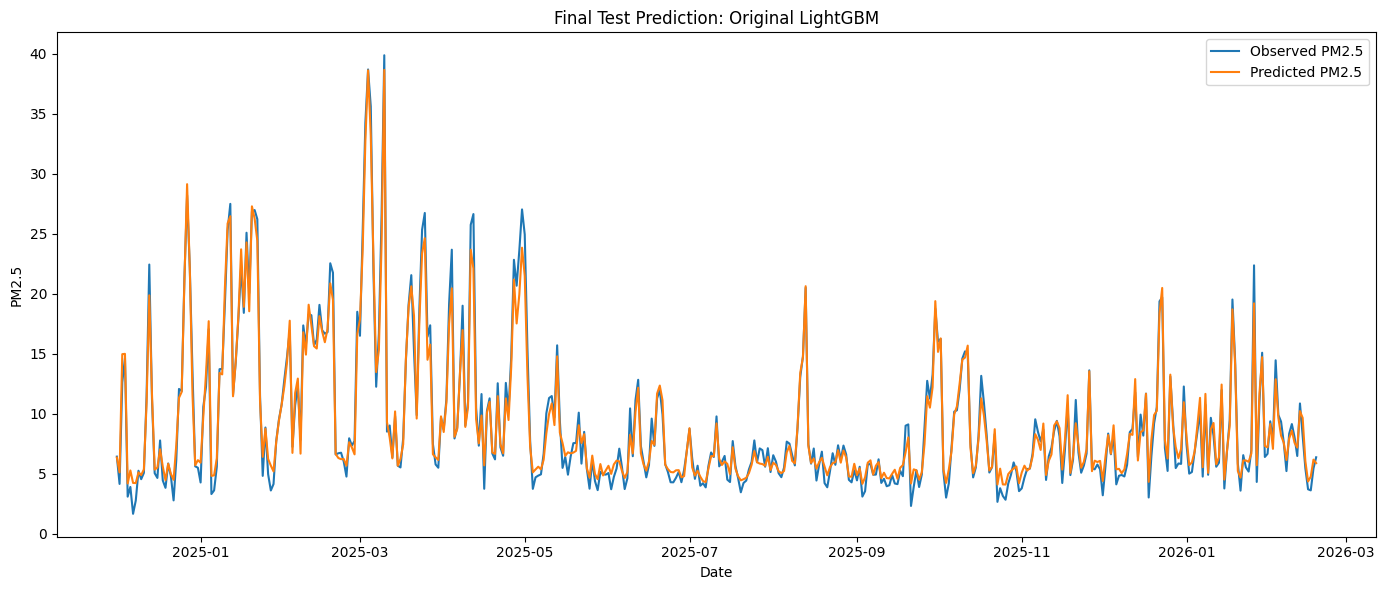

In [ ]:
# Create a dataframe containing test dates, observed values and predictions
test_plot_df = pd.DataFrame({
    "date": test_dates.reset_index(drop=True),
    "Observed PM2.5": y_test.reset_index(drop=True),
    "Predicted PM2.5": final_test_predictions
})

# Plot observed and predicted PM2.5 over the unseen test period
plt.figure(figsize=(14, 6))

plt.plot(
    test_plot_df["date"],
    test_plot_df["Observed PM2.5"],
    label="Observed PM2.5"
)

plt.plot(
    test_plot_df["date"],
    test_plot_df["Predicted PM2.5"],
    label="Predicted PM2.5"
)

plt.title(
    f"Final Test Prediction: {final_model_name}"
)

plt.xlabel("Date")
plt.ylabel("PM2.5")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Measure repeated prediction time to obtain a more stable inference estimate
latency_runs = 10

# Store the duration of each prediction run
latency_times = []

for _ in range(latency_runs):
    # Record the start time for one complete test prediction
    start_time = time.perf_counter()

    # Generate predictions for the test dataset
    final_model.predict(X_test)

    # Store the elapsed prediction time
    latency_times.append(
        time.perf_counter() - start_time
    )

# Calculate the average prediction time
average_prediction_time = np.mean(
    latency_times
)

# Calculate average inference latency per observation in milliseconds
average_latency_ms = (
    average_prediction_time
    / len(X_test)
) * 1000

# Display the inference measurements
print(
    "Average prediction time (seconds):",
    average_prediction_time
)

print(
    "Average inference latency per observation (ms):",
    average_latency_ms
)

Average prediction time (seconds): 0.007508374199915124
Average inference latency per observation (ms): 0.016872751011045222


In [ ]:
# Define the file used to store the final trained model
final_model_path = "final_lightgbm_model.joblib"

# Save the final model
joblib.dump(
    final_model,
    final_model_path
)

# Calculate the model file size in megabytes
final_model_size_mb = (
    os.path.getsize(final_model_path)
    / (1024 ** 2)
)

# Display the final model size
print(
    "Final model size (MB):",
    final_model_size_mb
)

Final model size (MB): 0.5416736602783203


In [ ]:
# Create a final deployment-oriented summary
deployment_summary = pd.DataFrame({
    "Model": [final_model_name],
    "Test MAE": [final_test_mae],
    "Test RMSE": [final_test_rmse],
    "Test R2": [final_test_r2],
    "Model Size MB": [final_model_size_mb],
    "Average Inference Time Seconds": [
        average_prediction_time
    ],
    "Average Latency ms per Observation": [
        average_latency_ms
    ]
})

# Display the final predictive and computational results
display(deployment_summary)

,Model,Test MAE,Test RMSE,Test R2,Model Size MB,Average Inference Time Seconds,Average Latency ms per Observation
0,Original LightGBM,0.750733,0.994533,0.974423,0.541674,0.007508,0.016873


In [ ]:
# Display columns containing PM2.5 target information before constructing the LSTM data
target_related_columns = [
    column
    for column in model_ready.columns
    if "pm2_5" in column.lower()
]

# Display the target-related columns for verification
print("PM2.5-related columns:")
print(target_related_columns)

# Display the first observations of the target-related variables
display(
    model_ready[
        target_related_columns
    ].head(10)
)

PM2.5-related columns:
['pm2_5', 'pm2_5_rolling_mean_3', 'pm2_5_rolling_mean_7', 'pm2_5_rolling_std_7', 'pm2_5_target', 'pm2_5_lag_1', 'pm2_5_lag_2', 'pm2_5_lag_3', 'pm2_5_lag_7']


,pm2_5,pm2_5_rolling_mean_3,pm2_5_rolling_mean_7,pm2_5_rolling_std_7,pm2_5_target,pm2_5_lag_1,pm2_5_lag_2,pm2_5_lag_3,pm2_5_lag_7
0,12.975000,8.845833,7.735119,3.210900,25.100000,5.550000,14.591667,6.395833,5.308333
1,25.100000,11.038889,8.830357,3.536229,11.337500,12.975000,5.550000,14.591667,7.020833
2,11.337500,14.541667,11.413095,6.949372,21.200000,25.100000,12.975000,5.550000,8.604167
3,21.200000,16.470833,11.803571,6.841186,20.545833,11.337500,25.100000,12.975000,6.675000
4,20.545833,19.212500,13.878571,7.218751,19.470833,21.200000,11.337500,25.100000,6.395833
5,19.470833,17.694444,15.900000,6.739437,23.233333,20.545833,21.200000,11.337500,14.591667
6,23.233333,20.405556,16.597024,6.833231,7.045833,19.470833,20.545833,21.200000,5.550000
7,7.045833,21.083333,19.123214,5.123323,4.362500,23.233333,19.470833,20.545833,12.975000
8,4.362500,16.583333,18.276190,6.589526,5.512500,7.045833,23.233333,19.470833,25.100000
9,5.512500,11.547222,15.313690,7.595203,3.404167,4.362500,7.045833,23.233333,11.337500


In [ ]:
# Remove the future target from the predictor list to prevent target leakage
feature_columns_lstm = [
    column
    for column in feature_columns
    if column != "pm2_5_target"
]

# Create the LSTM predictor dataset using only information available before prediction
X_lstm_source = model_ready[
    feature_columns_lstm
].copy()

# Define the actual next-day PM2.5 target
y_lstm_source = model_ready[
    "pm2_5_target"
].copy()

# Display the resulting dimensions
print("LSTM predictor shape:", X_lstm_source.shape)
print("LSTM target shape:", y_lstm_source.shape)

# Confirm that the future target is not present among the predictors
print(
    "\npm2_5_target included as predictor:",
    "pm2_5_target" in X_lstm_source.columns
)

LSTM predictor shape: (2964, 45)
LSTM target shape: (2964,)

pm2_5_target included as predictor: False


In [ ]:
# Create a fresh copy of the modelling data for the LSTM workflow
lstm_data = model_ready.copy()

# Remove the future target and non-predictive date column from the predictor list
feature_columns_lstm = [
    column
    for column in feature_columns
    if column != "pm2_5_target"
]

# Keep only numerical predictor variables
feature_columns_lstm = [
    column
    for column in feature_columns_lstm
    if pd.api.types.is_numeric_dtype(
        lstm_data[column]
    )
]

# Replace infinite predictor values with missing values
lstm_data[feature_columns_lstm] = (
    lstm_data[feature_columns_lstm]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

# Remove observations with a missing target
lstm_data = lstm_data.dropna(
    subset=["pm2_5_target"]
).copy()

# Sort the observations chronologically
lstm_data = (
    lstm_data
    .sort_values("date")
    .reset_index(drop=True)
)

# Display the dimensions before predictor imputation
print("LSTM dataset shape:", lstm_data.shape)

# Display the number of missing values in the target
print(
    "Missing LSTM targets:",
    lstm_data["pm2_5_target"].isna().sum()
)

LSTM dataset shape: (2963, 48)
Missing LSTM targets: 0


In [ ]:
# Calculate chronological split positions
lstm_train_end = int(
    len(lstm_data) * 0.70
)

lstm_validation_end = int(
    len(lstm_data) * 0.85
)

# Create the chronological training partition
lstm_train_df = lstm_data.iloc[
    :lstm_train_end
].copy()

# Create the chronological validation partition
lstm_validation_df = lstm_data.iloc[
    lstm_train_end:lstm_validation_end
].copy()

# Create the chronological test partition
lstm_test_df = lstm_data.iloc[
    lstm_validation_end:
].copy()

# Display the partition sizes
print("LSTM training observations:", len(lstm_train_df))
print(
    "LSTM validation observations:",
    len(lstm_validation_df)
)
print("LSTM testing observations:", len(lstm_test_df))

# Display the chronological boundaries
print(
    "\nTraining:",
    lstm_train_df["date"].min().date(),
    "to",
    lstm_train_df["date"].max().date()
)

print(
    "Validation:",
    lstm_validation_df["date"].min().date(),
    "to",
    lstm_validation_df["date"].max().date()
)

print(
    "Testing:",
    lstm_test_df["date"].min().date(),
    "to",
    lstm_test_df["date"].max().date()
)

LSTM training observations: 2074
LSTM validation observations: 444
LSTM testing observations: 445

Training: 2018-01-08 to 2023-09-12
Validation: 2023-09-13 to 2024-11-29
Testing: 2024-11-30 to 2026-02-17


In [ ]:
# Calculate predictor medians using the training partition only
lstm_medians = (
    lstm_train_df[feature_columns_lstm]
    .median()
)

# Apply the training-derived medians to all three partitions
lstm_train_df[feature_columns_lstm] = (
    lstm_train_df[feature_columns_lstm]
    .fillna(lstm_medians)
)

lstm_validation_df[feature_columns_lstm] = (
    lstm_validation_df[feature_columns_lstm]
    .fillna(lstm_medians)
)

lstm_test_df[feature_columns_lstm] = (
    lstm_test_df[feature_columns_lstm]
    .fillna(lstm_medians)
)

# Verify that no predictor missing values remain
print(
    "Training predictor missing values:",
    lstm_train_df[feature_columns_lstm]
    .isna()
    .sum()
    .sum()
)

print(
    "Validation predictor missing values:",
    lstm_validation_df[feature_columns_lstm]
    .isna()
    .sum()
    .sum()
)

print(
    "Test predictor missing values:",
    lstm_test_df[feature_columns_lstm]
    .isna()
    .sum()
    .sum()
)

# Verify that the target contains no missing values
print(
    "Training target missing values:",
    lstm_train_df["pm2_5_target"].isna().sum()
)

print(
    "Validation target missing values:",
    lstm_validation_df["pm2_5_target"].isna().sum()
)

print(
    "Test target missing values:",
    lstm_test_df["pm2_5_target"].isna().sum()
)

Training predictor missing values: 0
Validation predictor missing values: 0
Test predictor missing values: 0
Training target missing values: 0
Validation target missing values: 0
Test target missing values: 0


In [ ]:
# Create the feature scaler
lstm_scaler = StandardScaler()

# Fit the scaler only on the training predictors
X_lstm_train_scaled = lstm_scaler.fit_transform(
    lstm_train_df[feature_columns_lstm]
)

# Apply the training-based scaler to validation predictors
X_lstm_validation_scaled = lstm_scaler.transform(
    lstm_validation_df[feature_columns_lstm]
)

# Apply the same scaler to test predictors
X_lstm_test_scaled = lstm_scaler.transform(
    lstm_test_df[feature_columns_lstm]
)

# Extract the corresponding target arrays
y_lstm_train = (
    lstm_train_df["pm2_5_target"]
    .to_numpy()
)

y_lstm_validation = (
    lstm_validation_df["pm2_5_target"]
    .to_numpy()
)

y_lstm_test = (
    lstm_test_df["pm2_5_target"]
    .to_numpy()
)

# Verify that scaling produced finite values
print(
    "Training finite values:",
    np.isfinite(X_lstm_train_scaled).all()
)

print(
    "Validation finite values:",
    np.isfinite(X_lstm_validation_scaled).all()
)

print(
    "Test finite values:",
    np.isfinite(X_lstm_test_scaled).all()
)

Training finite values: True
Validation finite values: True
Test finite values: True


In [ ]:
# Define the number of historical observations used by each LSTM sequence
sequence_length = 7

# Create a function for generating chronological LSTM sequences
def create_lstm_sequences(features, targets, sequence_length):
    # Create containers for sequences and corresponding targets
    sequence_features = []
    sequence_targets = []

    # Generate one sequence for each prediction position
    for index in range(
        sequence_length,
        len(features)
    ):
        # Use the preceding observations as the model input
        sequence_features.append(
            features[
                index - sequence_length:index
            ]
        )

        # Use the current observation's target as the prediction target
        sequence_targets.append(
            targets[index]
        )

    # Convert the lists to numerical arrays
    return (
        np.asarray(sequence_features),
        np.asarray(sequence_targets)
    )

# Generate training sequences
X_lstm_train_seq, y_lstm_train_seq = (
    create_lstm_sequences(
        X_lstm_train_scaled,
        y_lstm_train,
        sequence_length
    )
)

# Generate validation sequences
X_lstm_validation_seq, y_lstm_validation_seq = (
    create_lstm_sequences(
        X_lstm_validation_scaled,
        y_lstm_validation,
        sequence_length
    )
)

# Generate test sequences
X_lstm_test_seq, y_lstm_test_seq = (
    create_lstm_sequences(
        X_lstm_test_scaled,
        y_lstm_test,
        sequence_length
    )
)

# Display sequence dimensions
print(
    "Training sequences:",
    X_lstm_train_seq.shape
)

print(
    "Validation sequences:",
    X_lstm_validation_seq.shape
)

print(
    "Test sequences:",
    X_lstm_test_seq.shape
)

Training sequences: (2067, 7, 45)
Validation sequences: (437, 7, 45)
Test sequences: (438, 7, 45)


In [ ]:
# Check every LSTM input and target array for missing or infinite values
lstm_arrays = {
    "X_train": X_lstm_train_seq,
    "y_train": y_lstm_train_seq,
    "X_validation": X_lstm_validation_seq,
    "y_validation": y_lstm_validation_seq,
    "X_test": X_lstm_test_seq,
    "y_test": y_lstm_test_seq
}

# Report the number of NaN and infinite values in every array
for name, array in lstm_arrays.items():
    print(
        name,
        "| NaN:",
        np.isnan(array).sum(),
        "| Infinite:",
        np.isinf(array).sum()
    )

X_train | NaN: 0 | Infinite: 0
y_train | NaN: 0 | Infinite: 0
X_validation | NaN: 0 | Infinite: 0
y_validation | NaN: 0 | Infinite: 0
X_test | NaN: 0 | Infinite: 0
y_test | NaN: 0 | Infinite: 0


In [ ]:
# Import TensorFlow for constructing and training the LSTM network
import tensorflow as tf

# Import the Keras Sequential model
from tensorflow.keras.models import Sequential

# Import the LSTM and Dense layers
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Import early stopping to prevent unnecessary neural-network training
from tensorflow.keras.callbacks import EarlyStopping

# Set TensorFlow random seeds for reproducibility
tf.random.set_seed(
    RANDOM_STATE
)

# Display the TensorFlow version used for the experiment
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Create the LSTM neural-network architecture
lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(
            X_lstm_train_seq.shape[1],
            X_lstm_train_seq.shape[2]
        ),
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(
        32,
        activation="relu"
    ),
    Dense(1)
])

# Configure the network for regression
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

# Display the model architecture
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        28,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,273 (118.25 KB)

 Trainable params: 30,273 (118.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Create early stopping to retain the best validation configuration
lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Measure the LSTM training duration
lstm_start = time.perf_counter()

# Train without shuffling because the observations are temporal
lstm_history = lstm_model.fit(
    X_lstm_train_seq,
    y_lstm_train_seq,
    validation_data=(
        X_lstm_validation_seq,
        y_lstm_validation_seq
    ),
    epochs=100,
    batch_size=32,
    shuffle=False,
    callbacks=[
        lstm_early_stopping
    ],
    verbose=1
)

# Calculate the training duration
lstm_training_time = (
    time.perf_counter()
    - lstm_start
)

# Display training time
print(
    "LSTM training time (seconds):",
    lstm_training_time
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 120.5986 - mae: 8.8043 - val_loss: 64.5321 - val_mae: 6.3938
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 44.8748 - mae: 4.4375 - val_loss: 26.2220 - val_mae: 3.6420
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37.7173 - mae: 4.2596 - val_loss: 24.7158 - val_mae: 3.5686
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.9111 - mae: 4.1786 - val_loss: 24.8037 - val_mae: 3.5826
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.7336 - mae: 4.0956 - val_loss: 24.8859 - val_mae: 3.6334
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.3095 - mae: 4.0431 - val_loss: 25.6465 - val_mae: 3.6532
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.8212 - mae: 4.0045 - val_loss: 26.4287 - val_mae: 3.6894
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.7670 - mae: 3.8992 - val_loss: 27.3048 - val_mae: 3.7862
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/s

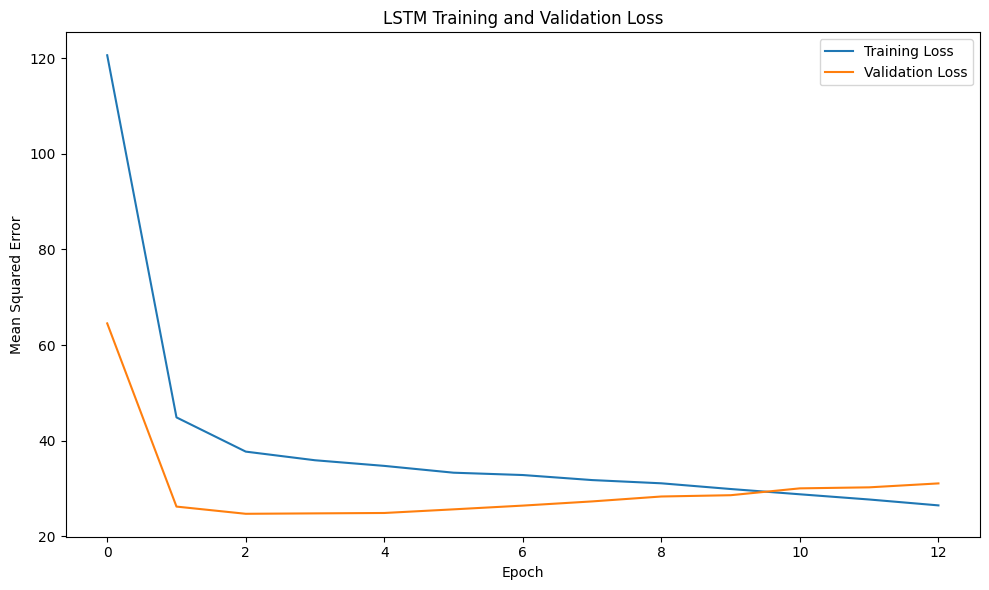

In [ ]:
# Plot the LSTM training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Generate predictions for the LSTM validation sequences
lstm_validation_predictions = (
    lstm_model.predict(
        X_lstm_validation_seq,
        verbose=0
    )
    .flatten()
)

# Calculate validation MAE
lstm_validation_mae = mean_absolute_error(
    y_lstm_validation_seq,
    lstm_validation_predictions
)

# Calculate validation RMSE
lstm_validation_rmse = np.sqrt(
    mean_squared_error(
        y_lstm_validation_seq,
        lstm_validation_predictions
    )
)

# Calculate validation R2
lstm_validation_r2 = r2_score(
    y_lstm_validation_seq,
    lstm_validation_predictions
)

# Display LSTM validation performance
print("LSTM Validation Results")
print("MAE:", lstm_validation_mae)
print("RMSE:", lstm_validation_rmse)
print("R2:", lstm_validation_r2)

LSTM Validation Results
MAE: 3.568625177271397
RMSE: 4.9714985432453025
R2: 0.07480367531574761


In [ ]:
# Generate predictions for the untouched LSTM test sequences
lstm_test_predictions = (
    lstm_model.predict(
        X_lstm_test_seq,
        verbose=0
    )
    .flatten()
)

# Verify that the predictions contain no invalid values
print(
    "NaN predictions:",
    np.isnan(lstm_test_predictions).sum()
)

print(
    "Infinite predictions:",
    np.isinf(lstm_test_predictions).sum()
)

# Calculate test MAE
lstm_test_mae = mean_absolute_error(
    y_lstm_test_seq,
    lstm_test_predictions
)

# Calculate test RMSE
lstm_test_rmse = np.sqrt(
    mean_squared_error(
        y_lstm_test_seq,
        lstm_test_predictions
    )
)

# Calculate test R2
lstm_test_r2 = r2_score(
    y_lstm_test_seq,
    lstm_test_predictions
)

# Display final LSTM test performance
lstm_test_results = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_test_mae],
    "RMSE": [lstm_test_rmse],
    "R2": [lstm_test_r2]
})

display(lstm_test_results)

NaN predictions: 0
Infinite predictions: 0


,Model,MAE,RMSE,R2
0,LSTM,4.172248,5.563403,0.202874


In [ ]:
# Define the file path for saving the trained LSTM model
lstm_model_path = "final_lstm_model.keras"

# Save the trained LSTM model to disk
lstm_model.save(
    lstm_model_path
)

# Calculate the saved LSTM model size in megabytes
lstm_model_size_mb = (
    os.path.getsize(
        lstm_model_path
    )
    / (1024 ** 2)
)

# Display the LSTM model size
print(
    "LSTM model size (MB):",
    lstm_model_size_mb
)

LSTM model size (MB): 0.3762826919555664


In [ ]:
# Create a copy of the test predictors for final model evaluation
X_test_final = X_test.copy()

# Replace infinite predictor values with missing values before imputation
X_test_final = X_test_final.replace(
    [np.inf, -np.inf],
    np.nan
)

# Use the training-derived medians to avoid information leakage
X_test_final = X_test_final.fillna(
    X_train.median()
)

# Confirm that no missing predictor values remain
print(
    "Missing values in final test predictors:",
    X_test_final.isna().sum().sum()
)

# Generate final test predictions for each conventional model
dummy_test_predictions = dummy_model.predict(
    X_test_final
)

rf_test_predictions = rf_model.predict(
    X_test_final
)

gb_test_predictions = gb_model.predict(
    X_test_final
)

lgbm_test_predictions = final_model.predict(
    X_test_final
)

# Calculate final test metrics for all conventional models
final_test_comparison = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Random Forest",
        "Gradient Boosting",
        "LightGBM",
        "LSTM"
    ],
    "MAE": [
        mean_absolute_error(
            y_test,
            dummy_test_predictions
        ),
        mean_absolute_error(
            y_test,
            rf_test_predictions
        ),
        mean_absolute_error(
            y_test,
            gb_test_predictions
        ),
        mean_absolute_error(
            y_test,
            lgbm_test_predictions
        ),
        lstm_test_mae
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_test,
                dummy_test_predictions
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                rf_test_predictions
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                gb_test_predictions
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                lgbm_test_predictions
            )
        ),
        lstm_test_rmse
    ],
    "R2": [
        r2_score(
            y_test,
            dummy_test_predictions
        ),
        r2_score(
            y_test,
            rf_test_predictions
        ),
        r2_score(
            y_test,
            gb_test_predictions
        ),
        r2_score(
            y_test,
            lgbm_test_predictions
        ),
        lstm_test_r2
    ]
})

# Sort the models by test MAE
final_test_comparison = (
    final_test_comparison
    .sort_values(
        "MAE",
        ascending=True
    )
    .reset_index(drop=True)
)

# Display the final test comparison
display(final_test_comparison)

Missing values in final test predictors: 0


,Model,MAE,RMSE,R2
0,LightGBM,0.750140,0.994320,0.974434
1,Gradient Boosting,0.816226,1.125690,0.967233
2,Random Forest,1.050690,1.419269,0.947913
3,LSTM,4.172248,5.563403,0.202874
4,Dummy Regressor,4.921401,6.272322,-0.017326


In [ ]:
# Calculate final test metrics for each conventional model
rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_predictions
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_predictions
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_predictions
)

gb_test_mae = mean_absolute_error(
    y_test,
    gb_test_predictions
)

gb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_test_predictions
    )
)

gb_test_r2 = r2_score(
    y_test,
    gb_test_predictions
)

# Create a validation and test comparison for the main predictive models
validation_test_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "LightGBM",
        "LSTM"
    ],
    "Validation MAE": [
        rf_validation_mae,
        gb_validation_mae,
        lgbm_validation_mae,
        lstm_validation_mae
    ],
    "Test MAE": [
        rf_test_mae,
        gb_test_mae,
        final_test_mae,
        lstm_test_mae
    ],
    "Validation RMSE": [
        rf_validation_rmse,
        gb_validation_rmse,
        lgbm_validation_rmse,
        lstm_validation_rmse
    ],
    "Test RMSE": [
        rf_test_rmse,
        gb_test_rmse,
        final_test_rmse,
        lstm_test_rmse
    ],
    "Validation R2": [
        rf_validation_r2,
        gb_validation_r2,
        lgbm_validation_r2,
        lstm_validation_r2
    ],
    "Test R2": [
        rf_test_r2,
        gb_test_r2,
        final_test_r2,
        lstm_test_r2
    ]
})

# Display the validation and test comparison
display(validation_test_comparison)

,Model,Validation MAE,Test MAE,Validation RMSE,Test RMSE,Validation R2,Test R2
0,Random Forest,0.981876,1.050690,1.263475,1.419269,0.939693,0.947913
1,Gradient Boosting,0.771023,0.816226,1.032023,1.125690,0.959764,0.967233
2,LightGBM,0.705116,0.750733,0.945496,0.994533,0.966228,0.974423
3,LSTM,3.568625,4.172248,4.971499,5.563403,0.074804,0.202874


In [ ]:
# Store the final test predictions for all evaluated models
final_test_predictions_all = {
    "Dummy Regressor": dummy_test_predictions,
    "Random Forest": rf_test_predictions,
    "Gradient Boosting": gb_test_predictions,
    "LightGBM": lgbm_test_predictions,
    "LSTM": lstm_test_predictions
}

# Verify that every model produced the expected number of predictions
for model_name, predictions in final_test_predictions_all.items():
    print(
        model_name,
        "predictions:",
        len(predictions)
    )

Dummy Regressor predictions: 445
Random Forest predictions: 445
Gradient Boosting predictions: 445
LightGBM predictions: 445
LSTM predictions: 438


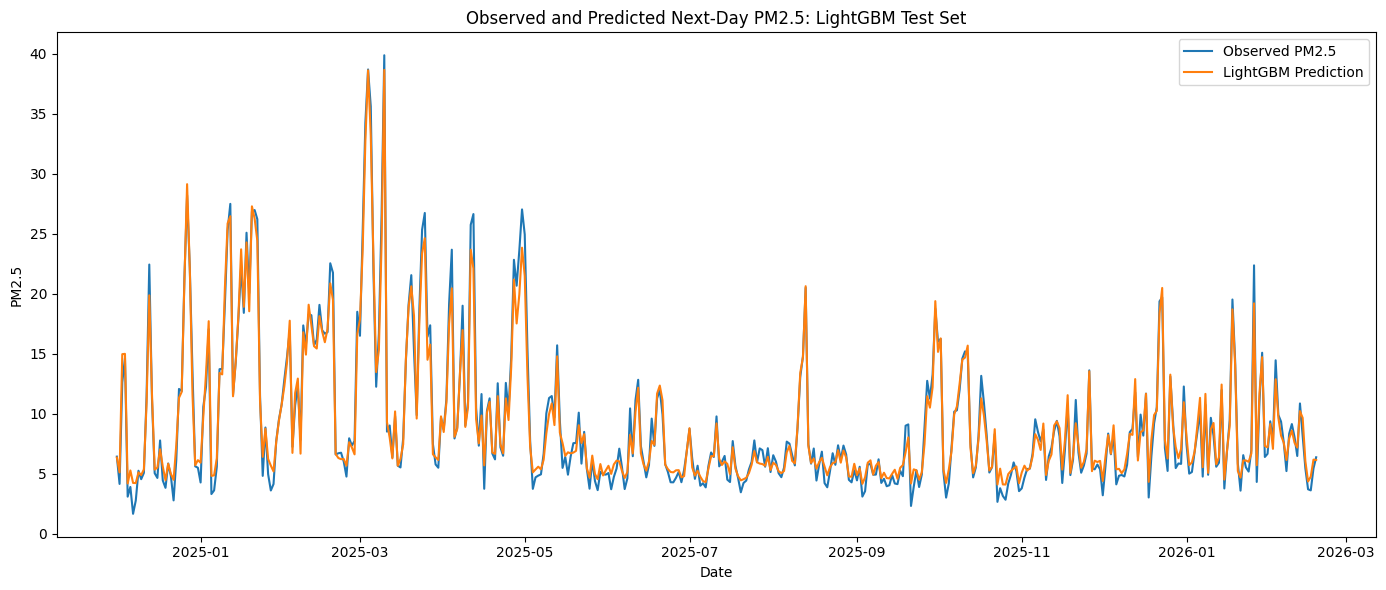

In [ ]:
# Create a dataframe containing the final LightGBM test observations and predictions
lightgbm_test_plot_df = pd.DataFrame({
    "date": test_dates.reset_index(drop=True),
    "Observed PM2.5": y_test.reset_index(drop=True),
    "Predicted PM2.5": lgbm_test_predictions
})

# Plot observed and predicted PM2.5 values over the test period
plt.figure(figsize=(14, 6))

plt.plot(
    lightgbm_test_plot_df["date"],
    lightgbm_test_plot_df["Observed PM2.5"],
    label="Observed PM2.5"
)

plt.plot(
    lightgbm_test_plot_df["date"],
    lightgbm_test_plot_df["Predicted PM2.5"],
    label="LightGBM Prediction"
)

plt.title(
    "Observed and Predicted Next-Day PM2.5: LightGBM Test Set"
)

plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

,0
count,445.000000
mean,-0.001570
std,0.995438
min,-2.931126
25%,-0.657522
50%,-0.092777
75%,0.506945
max,4.536051


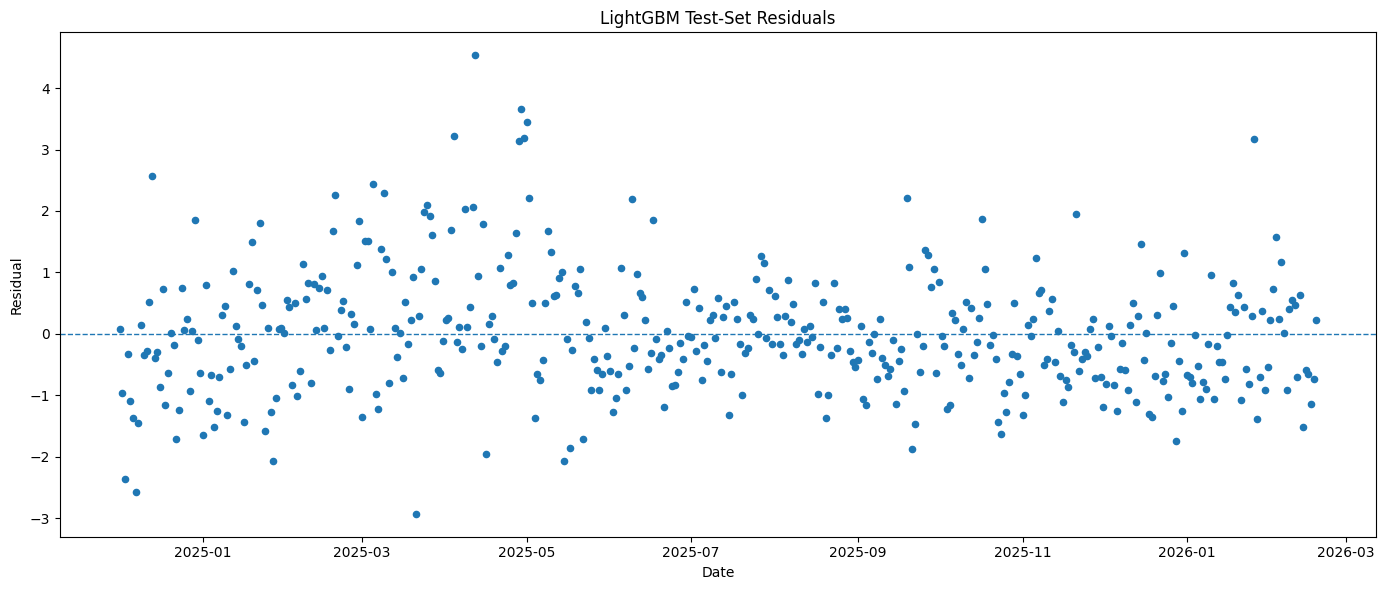

In [ ]:
# Calculate residuals using observed minus predicted PM2.5
lightgbm_test_residuals = (
    y_test.reset_index(drop=True)
    - pd.Series(
        lgbm_test_predictions
    )
)

# Display descriptive statistics of the residuals
display(
    lightgbm_test_residuals.describe()
)

# Plot residuals over the test period
plt.figure(figsize=(14, 6))

plt.scatter(
    test_dates.reset_index(drop=True),
    lightgbm_test_residuals,
    s=20
)

# Add a zero-error reference line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "LightGBM Test-Set Residuals"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

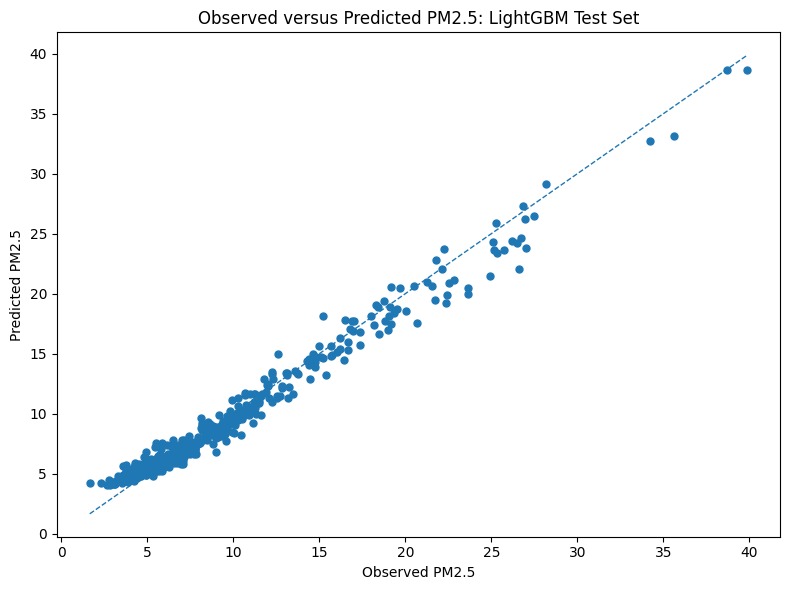

In [ ]:
# Create a scatter plot of observed and predicted PM2.5 values
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    lgbm_test_predictions,
    s=25
)

# Define the range for the perfect-prediction reference line
minimum_value = min(
    y_test.min(),
    lgbm_test_predictions.min()
)

maximum_value = max(
    y_test.max(),
    lgbm_test_predictions.max()
)

# Add the perfect-prediction reference line
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1
)

plt.title(
    "Observed versus Predicted PM2.5: LightGBM Test Set"
)

plt.xlabel("Observed PM2.5")
plt.ylabel("Predicted PM2.5")

plt.tight_layout()
plt.show()

In [ ]:
# Define the number of repeated LSTM inference measurements
lstm_latency_runs = 10

# Store the duration of each LSTM inference run
lstm_latency_times = []

# Measure LSTM inference time repeatedly on the test sequences
for _ in range(lstm_latency_runs):

    # Record the start time
    start_time = time.perf_counter()

    # Generate predictions for the LSTM test sequences
    lstm_model.predict(
        X_lstm_test_seq,
        verbose=0
    )

    # Store the elapsed inference time
    lstm_latency_times.append(
        time.perf_counter() - start_time
    )

# Calculate the average total LSTM inference time
lstm_average_prediction_time = np.mean(
    lstm_latency_times
)

# Calculate the average LSTM latency per observation in milliseconds
lstm_average_latency_ms = (
    lstm_average_prediction_time
    / len(X_lstm_test_seq)
) * 1000

# Display the LSTM inference measurements
print(
    "Average LSTM prediction time (seconds):",
    lstm_average_prediction_time
)

print(
    "Average LSTM latency per observation (ms):",
    lstm_average_latency_ms
)

Average LSTM prediction time (seconds): 0.08900873950005916
Average LSTM latency per observation (ms): 0.20321630022844558


In [ ]:
# Define the conventional models used in the final comparison
tabular_models = {
    "Dummy Regressor": dummy_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "LightGBM": final_model
}

# Define file paths for the saved conventional models
model_paths = {
    "Dummy Regressor": "dummy_regressor_final.joblib",
    "Random Forest": "random_forest_final.joblib",
    "Gradient Boosting": "gradient_boosting_final.joblib",
    "LightGBM": "lightgbm_final.joblib"
}

# Save each conventional model
for model_name, model_path in model_paths.items():

    # Save the trained model
    joblib.dump(
        tabular_models[model_name],
        model_path
    )

# Create a dictionary for storing model sizes
model_size_results = {}

# Calculate the size of each conventional model
for model_name, model_path in model_paths.items():

    # Convert the saved file size from bytes to megabytes
    model_size_results[model_name] = (
        os.path.getsize(
            model_path
        )
        / (1024 ** 2)
    )

# Add the measured LSTM model size
model_size_results["LSTM"] = lstm_model_size_mb

# Convert the model-size results into a dataframe
model_size_comparison = pd.DataFrame({
    "Model": list(
        model_size_results.keys()
    ),
    "Model Size MB": list(
        model_size_results.values()
    )
})

# Display the model-size comparison
display(model_size_comparison)

,Model,Model Size MB
0,Dummy Regressor,0.001342
1,Random Forest,35.945939
2,Gradient Boosting,0.255318
3,LightGBM,0.541674
4,LSTM,0.376283


In [ ]:
# Define the number of repeated inference measurements
latency_runs = 10

# Store the conventional models for consistent latency evaluation
tabular_models = {
    "Dummy Regressor": dummy_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "LightGBM": final_model
}

# Create a container for inference measurements
inference_results = {}

# Measure inference time for each conventional model
for model_name, model in tabular_models.items():

    # Store the duration of each repeated prediction run
    run_times = []

    for _ in range(latency_runs):

        # Record the start time
        start_time = time.perf_counter()

        # Generate predictions using the cleaned test predictors
        model.predict(
            X_test_final
        )

        # Record the elapsed prediction time
        run_times.append(
            time.perf_counter() - start_time
        )

    # Calculate average total inference time
    average_time = np.mean(
        run_times
    )

    # Convert total inference time into milliseconds per observation
    latency_ms = (
        average_time
        / len(X_test_final)
    ) * 1000

    # Store the computational measurements
    inference_results[model_name] = {
        "Total Inference Time (s)": average_time,
        "Latency per Observation (ms)": latency_ms
    }

# Add the measured LSTM inference results
inference_results["LSTM"] = {
    "Total Inference Time (s)": lstm_average_prediction_time,
    "Latency per Observation (ms)": lstm_average_latency_ms
}

# Convert the inference results into a dataframe
inference_comparison = (
    pd.DataFrame.from_dict(
        inference_results,
        orient="index"
    )
    .reset_index()
    .rename(
        columns={
            "index": "Model"
        }
    )
)

# Display the inference comparison
display(inference_comparison)

,Model,Total Inference Time (s),Latency per Observation (ms)
0,Dummy Regressor,0.000077,0.000174
1,Random Forest,0.056028,0.125905
2,Gradient Boosting,0.002632,0.005916
3,LightGBM,0.007669,0.017234
4,LSTM,0.089009,0.203216


In [ ]:
# Combine predictive performance, inference performance and model size
deployment_final = (
    final_test_comparison
    .merge(
        inference_comparison,
        on="Model",
        how="left"
    )
    .merge(
        model_size_comparison,
        on="Model",
        how="left"
    )
)

# Keep the columns required for the deployment comparison
deployment_final = deployment_final[
    [
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "Model Size MB",
        "Total Inference Time (s)",
        "Latency per Observation (ms)"
    ]
]

# Sort models by predictive error
deployment_final = (
    deployment_final
    .sort_values(
        "MAE",
        ascending=True
    )
    .reset_index(drop=True)
)

# Display the final comparison
display(deployment_final)

,Model,MAE,RMSE,R2,Model Size MB,Total Inference Time (s),Latency per Observation (ms)
0,LightGBM,0.750140,0.994320,0.974434,0.541674,0.007669,0.017234
1,Gradient Boosting,0.816226,1.125690,0.967233,0.255318,0.002632,0.005916
2,Random Forest,1.050690,1.419269,0.947913,35.945939,0.056028,0.125905
3,LSTM,4.172248,5.563403,0.202874,0.376283,0.089009,0.203216
4,Dummy Regressor,4.921401,6.272322,-0.017326,0.001342,0.000077,0.000174


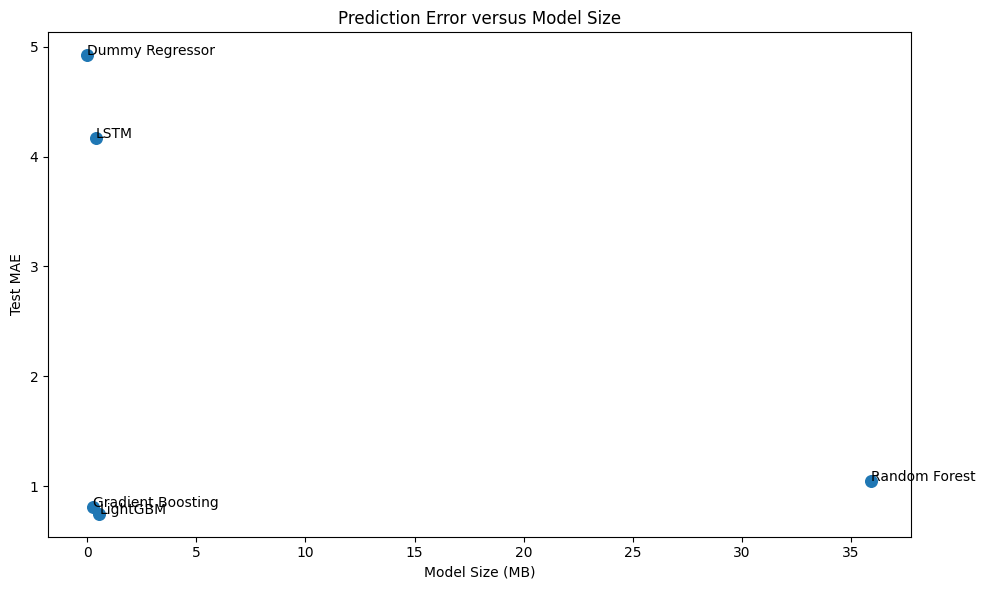

In [ ]:
# Compare predictive error with model storage requirements
plt.figure(figsize=(10, 6))

plt.scatter(
    deployment_final["Model Size MB"],
    deployment_final["MAE"],
    s=70
)

# Add model names to the plotted points
for _, row in deployment_final.iterrows():
    plt.annotate(
        row["Model"],
        (
            row["Model Size MB"],
            row["MAE"]
        )
    )

plt.title(
    "Prediction Error versus Model Size"
)

plt.xlabel("Model Size (MB)")
plt.ylabel("Test MAE")

plt.tight_layout()
plt.show()

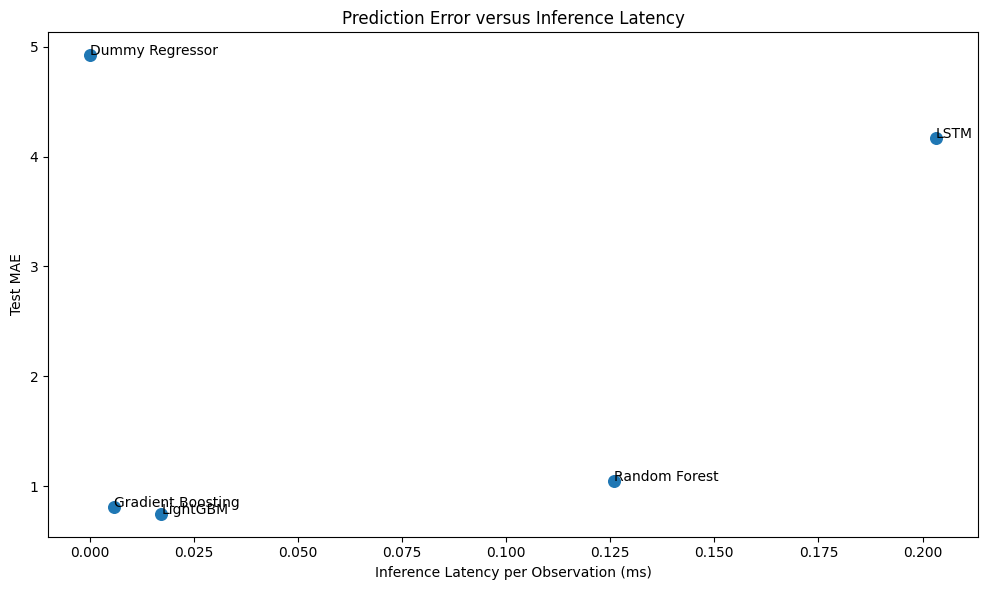

In [ ]:
# Compare predictive error with inference latency
plt.figure(figsize=(10, 6))

plt.scatter(
    deployment_final["Latency per Observation (ms)"],
    deployment_final["MAE"],
    s=70
)

# Add model names to the plotted points
for _, row in deployment_final.iterrows():
    plt.annotate(
        row["Model"],
        (
            row["Latency per Observation (ms)"],
            row["MAE"]
        )
    )

plt.title(
    "Prediction Error versus Inference Latency"
)

plt.xlabel(
    "Inference Latency per Observation (ms)"
)

plt.ylabel(
    "Test MAE"
)

plt.tight_layout()
plt.show()